In [1]:
"""
Parking Violation Hotspot Detection & Impact Scoring
======================================================
Input  : CSV with columns -
    id, latitude, longitude, location, vehicle_number, vehicle_type,
    description, violation_type, offence_code, created_datetime,
    closed_datetime, modified_datetime, device_id, created_by_id,
    center_code, police_station, data_sent_to_scita, junction_name,
    action_taken_timestamp, data_sent_to_scita_timestamp,
    updated_vehicle_number, updated_vehicle_type, validation_status,
    validation_timestamp

Output :
    1. hotspots.csv      -> one row per cluster, with rank + impact score
    2. violations_scored.csv -> original rows tagged with cluster_id + scores
    3. hotspots.geojson  -> for direct map rendering (frontend)

Pipeline:
    1. Load + clean
    2. Parse violation_type / offence_code (stringified JSON arrays)
    3. Feature engineering (time-of-day, junction flag, severity)
    4. Geo-clustering with DBSCAN (haversine metric, meters-based eps)
    5. Composite "Hotspot Impact Score" per cluster
    6. Rank + export
"""

import ast
import json
import math
import sys

import numpy as np
import pandas as pd

# ----------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------
INPUT_CSV = "jan to may police violation_anonymized791b166 (1).csv"          # <-- change to your file path
OUTPUT_DIR = "."

GRID_CELL_SIZE_METERS = 60      # size of each fixed hotspot cell (tune: 30-150m typical)
GRID_MIN_SAMPLES = 6            # min violations in a cell to count as a hotspot

PEAK_HOURS = set(list(range(8, 11)) + list(range(18, 21)))  # 8-10am, 6-8pm

# Severity weights per violation keyword (tune based on domain input)
SEVERITY_WEIGHTS = {
    "WRONG PARKING": 1.5,
    "PARKING NEAR ROAD CROSSING": 2.0,
    "PARKING IN A MAIN ROAD": 2.0,
    "NO PARKING": 1.0,
}
DEFAULT_SEVERITY = 1.0

# Vehicle footprint weight (bigger vehicles block more road -> higher impact)
VEHICLE_WEIGHTS = {
    "CAR": 1.0,
    "SCOOTER": 0.4,
    "PASSENGER AUTO": 0.7,
    "TANKER": 2.5,
    "MAXI-CAB": 1.3,
    "TRUCK": 2.5,
    "BUS": 2.5,
}
DEFAULT_VEHICLE_WEIGHT = 1.0


# ----------------------------------------------------------------------
# STEP 1: LOAD + CLEAN
# ----------------------------------------------------------------------
def load_and_clean(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, dtype=str)

    # Normalize NULL-like strings to actual NaN
    df = df.replace({"NULL": np.nan, "null": np.nan, "": np.nan})
    df = df.infer_objects()

    # Drop rows without coordinates
    df = df.dropna(subset=["latitude", "longitude"])
    df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
    df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
    df = df.dropna(subset=["latitude", "longitude"])

    # Keep only verified/approved violations (drop rejected + unvalidated noise)
    if "validation_status" in df.columns:
        df = df[df["validation_status"].fillna("approved") != "rejected"]

    # Parse timestamps
    for col in ["created_datetime", "closed_datetime", "modified_datetime"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

    df = df.dropna(subset=["created_datetime"])
    df["hour"] = df["created_datetime"].dt.hour
    df["dayofweek"] = df["created_datetime"].dt.dayofweek  # 0=Mon

    return df.reset_index(drop=True)


# ----------------------------------------------------------------------
# STEP 2: PARSE VIOLATION TYPE / OFFENCE CODE (stringified lists)
# ----------------------------------------------------------------------
def safe_parse_list(val):
    if pd.isna(val):
        return []
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return parsed
        return [parsed]
    except (ValueError, SyntaxError):
        return [val]


def parse_violations(df: pd.DataFrame) -> pd.DataFrame:
    df["violation_list"] = df["violation_type"].apply(safe_parse_list)
    df["offence_list"] = df["offence_code"].apply(safe_parse_list)
    return df


# ----------------------------------------------------------------------
# STEP 3: FEATURE ENGINEERING
# ----------------------------------------------------------------------
def severity_score(violation_list):
    if not violation_list:
        return DEFAULT_SEVERITY
    scores = [SEVERITY_WEIGHTS.get(v, DEFAULT_SEVERITY) for v in violation_list]
    return max(scores)  # worst violation present drives severity


def vehicle_weight(vtype):
    if pd.isna(vtype):
        return DEFAULT_VEHICLE_WEIGHT
    return VEHICLE_WEIGHTS.get(str(vtype).upper(), DEFAULT_VEHICLE_WEIGHT)


def is_peak_hour(hour):
    return 1.5 if hour in PEAK_HOURS else 1.0


def near_junction(junction_name):
    if pd.isna(junction_name):
        return 1.0
    return 1.0 if str(junction_name).strip().lower() == "no junction" else 1.6


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df["severity_score"] = df["violation_list"].apply(severity_score)
    df["vehicle_weight"] = df["vehicle_type"].apply(vehicle_weight)
    df["peak_hour_weight"] = df["hour"].apply(is_peak_hour)
    df["junction_weight"] = df["junction_name"].apply(near_junction)

    # Per-violation impact score (used later, aggregated per cluster)
    df["violation_impact"] = (
        df["severity_score"]
        * df["vehicle_weight"]
        * df["peak_hour_weight"]
        * df["junction_weight"]
    )
    return df


# ----------------------------------------------------------------------
# STEP 4: GEO-BINNING (fixed-size square grid -> bounded hotspot cells)
# ----------------------------------------------------------------------
# Why grid binning instead of DBSCAN:
#   DBSCAN chains points through density-reachability — in dense urban
#   data this merges streets that are kilometers apart into one giant
#   "cluster" (observed: a single DBSCAN cluster spanning ~3.7km x 3.0km).
#   A fixed-size grid guarantees every hotspot is bounded to exactly
#   GRID_CELL_SIZE_METERS x GRID_CELL_SIZE_METERS, by construction —
#   no chaining is possible.
EARTH_METERS_PER_DEGREE_LAT = 111320.0


def latlon_to_grid_cell(lat: np.ndarray, lon: np.ndarray, cell_size_m: float):
    """Snap lat/lon arrays to integer grid cell IDs of fixed real-world size."""
    lat_m = lat * EARTH_METERS_PER_DEGREE_LAT
    lon_m = lon * EARTH_METERS_PER_DEGREE_LAT * np.cos(np.radians(lat))
    cell_row = np.floor(lat_m / cell_size_m).astype(np.int64)
    cell_col = np.floor(lon_m / cell_size_m).astype(np.int64)
    return cell_row, cell_col


def cluster_hotspots(df: pd.DataFrame, cell_size_m=GRID_CELL_SIZE_METERS,
                      min_samples=GRID_MIN_SAMPLES) -> pd.DataFrame:
    lat = df["latitude"].to_numpy()
    lon = df["longitude"].to_numpy()

    cell_row, cell_col = latlon_to_grid_cell(lat, lon, cell_size_m)

    # Unique, stable integer ID per (row, col) grid cell
    df["grid_row"] = cell_row
    df["grid_col"] = cell_col
    grid_key = pd.Series(list(zip(cell_row, cell_col)))
    df["cluster_id"] = grid_key.astype("category").cat.codes.to_numpy()

    # Mark cells below the density threshold as noise (-1), same convention as before
    counts = df.groupby("cluster_id")["cluster_id"].transform("count")
    df.loc[counts < min_samples, "cluster_id"] = -1

    return df


# ----------------------------------------------------------------------
# STEP 5: COMPOSITE HOTSPOT IMPACT SCORE PER CLUSTER
# ----------------------------------------------------------------------
def score_clusters(df: pd.DataFrame) -> pd.DataFrame:
    hotspots = df[df["cluster_id"] != -1].copy()

    grouped = hotspots.groupby("cluster_id").agg(
        violation_count=("id", "count"),
        avg_lat=("latitude", "mean"),
        avg_lon=("longitude", "mean"),
        total_impact=("violation_impact", "sum"),
        avg_impact=("violation_impact", "mean"),
        top_police_station=("police_station", lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        top_junction=("junction_name", lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        date_span_days=("created_datetime", lambda x: max((x.max() - x.min()).days, 1)),
        unique_days=("created_datetime", lambda x: x.dt.date.nunique()),
        dominant_violation=("violation_list", lambda lists: pd.Series(
            [v for sub in lists for v in sub]).mode().iloc[0]
            if any(lists) else "UNKNOWN"),
    ).reset_index()

    # Recurrence rate: how consistently this spot gets violations (not a one-off)
    grouped["recurrence_rate"] = grouped["unique_days"] / grouped["date_span_days"]

    # Final Hotspot Impact Score (tune weights as needed)
    grouped["hotspot_impact_score"] = (
        grouped["total_impact"] * 0.6
        + grouped["violation_count"] * 0.25
        + grouped["recurrence_rate"] * 100 * 0.15
    )

    grouped = grouped.sort_values("hotspot_impact_score", ascending=False).reset_index(drop=True)
    grouped["rank"] = grouped.index + 1

    return grouped


# ----------------------------------------------------------------------
# STEP 6: EXPORT (CSV + GeoJSON for map rendering)
# ----------------------------------------------------------------------
def export_geojson(hotspots: pd.DataFrame, path: str):
    features = []
    for _, row in hotspots.iterrows():
        features.append({
            "type": "Feature",
            "geometry": {
                "type": "Point",
                "coordinates": [row["avg_lon"], row["avg_lat"]],
            },
            "properties": {
                "cluster_id": int(row["cluster_id"]),
                "rank": int(row["rank"]),
                "violation_count": int(row["violation_count"]),
                "hotspot_impact_score": round(float(row["hotspot_impact_score"]), 2),
                "recurrence_rate": round(float(row["recurrence_rate"]), 2),
                "police_station": row["top_police_station"],
                "junction": row["top_junction"],
                "dominant_violation": row["dominant_violation"],
            },
        })

    geojson = {"type": "FeatureCollection", "features": features}
    with open(path, "w") as f:
        json.dump(geojson, f, indent=2)


# ----------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------
def main(input_csv=INPUT_CSV, output_dir=OUTPUT_DIR):
    print(f"Loading {input_csv} ...")
    df = load_and_clean(input_csv)
    print(f"  {len(df)} valid records after cleaning")

    df = parse_violations(df)
    df = engineer_features(df)

    print("Running grid-based hotspot binning ...")
    df = cluster_hotspots(df)
    n_clusters = df["cluster_id"].nunique() - (1 if -1 in df["cluster_id"].values else 0)
    print(f"  {n_clusters} hotspot cells found (each <= {GRID_CELL_SIZE_METERS}m x {GRID_CELL_SIZE_METERS}m), "
          f"{(df['cluster_id'] == -1).sum()} sparse/noise points excluded "
          f"(cells with fewer than {GRID_MIN_SAMPLES} violations)")

    hotspots = score_clusters(df)

    violations_out = f"{output_dir}/violations_scored.csv"
    hotspots_out = f"{output_dir}/hotspots.csv"
    geojson_out = f"{output_dir}/hotspots.geojson"

    df.drop(columns=["violation_list", "offence_list", "grid_row", "grid_col"]).to_csv(violations_out, index=False)
    hotspots.to_csv(hotspots_out, index=False)
    export_geojson(hotspots, geojson_out)

    print(f"\nSaved:\n  {violations_out}\n  {hotspots_out}\n  {geojson_out}")
    print("\nTop 5 hotspots:")
    print(hotspots[["rank", "violation_count", "hotspot_impact_score",
                     "top_police_station", "top_junction"]].head(5).to_string(index=False))


if __name__ == "__main__":
    # Detect notebook/Jupyter/Colab environments (sys.argv[1] there is a
    # kernel connection file like "-f", not a real CSV path) vs real
    # terminal usage like: python3 parking_hotspot_ml.py data.csv
    def _is_notebook_arg(arg: str) -> bool:
        return arg.startswith("-") or arg.endswith(".json")

    if len(sys.argv) > 1 and not _is_notebook_arg(sys.argv[1]):
        csv_path = sys.argv[1]
    else:
        csv_path = INPUT_CSV  # <-- edit INPUT_CSV above, or call main("your_file.csv") directly

    main(csv_path)

Loading jan to may police violation_anonymized791b166 (1).csv ...


/tmp/ipykernel_2162/2583776527.py:75: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"NULL": np.nan, "null": np.nan, "": np.nan})


  248691 valid records after cleaning
Running grid-based hotspot binning ...
  4814 hotspot cells found (each <= 60m x 60m), 16764 sparse/noise points excluded (cells with fewer than 6 violations)

Saved:
  ./violations_scored.csv
  ./hotspots.csv
  ./hotspots.geojson

Top 5 hotspots:
 rank  violation_count  hotspot_impact_score top_police_station                     top_junction
    1             1976           2390.516000       Shivajinagar   BTP051 - Safina Plaza Junction
    2             1315           1791.750537        City Market      BTP082 - KR Market Junction
    3             1119           1545.930000    HAL Old Airport                      No Junction
    4             1266           1526.984000       Shivajinagar BTP211 - Central Street Junction
    5             1864           1455.210979    HAL Old Airport                      No Junction


In [2]:
import pandas as pd
df = pd.read_csv("violations_scored.csv")
top = df[df["cluster_id"] == df.loc[df.groupby("cluster_id")["id"].transform("count").idxmax(), "cluster_id"]]
print(top["latitude"].min(), top["latitude"].max())
print(top["longitude"].min(), top["longitude"].max())

12.8026667 13.29368437
77.442553 77.771735


In [3]:
hotspots = pd.read_csv("hotspots.csv")
hotspots.describe()
hotspots.head(20)

,cluster_id,violation_count,avg_lat,avg_lon,total_impact,avg_impact,top_police_station,top_junction,date_span_days,unique_days,dominant_violation,recurrence_rate,hotspot_impact_score,rank
0,7374,1976,12.981138,77.610161,3136.360,1.587227,Shivajinagar,BTP051 - Safina Plaza Junction,150,147,NO PARKING,0.980000,2390.516000,1
1,5067,1315,12.964001,77.576850,2418.200,1.838935,City Market,BTP082 - KR Market Junction,149,120,WRONG PARKING,0.805369,1791.750537,2
2,3188,1119,12.939751,77.695559,2102.800,1.879178,HAL Old Airport,No Junction,140,42,WRONG PARKING,0.300000,1545.930000,3
3,7708,1266,12.984003,77.603611,1996.640,1.577125,Shivajinagar,BTP211 - Central Street Junction,150,125,NO PARKING,0.833333,1526.984000,4
4,2727,1864,12.933781,77.690874,1633.650,0.876422,HAL Old Airport,No Junction,143,86,NO PARKING,0.601399,1455.210979,5
5,5135,1076,12.964528,77.576502,1562.800,1.452416,City Market,BTP082 - KR Market Junction,148,107,WRONG PARKING,0.722973,1217.524595,6
6,7356,1267,12.981155,77.598475,1471.600,1.161484,Shivajinagar,BTP042 - Minsk Square Junction (CTO),141,82,WRONG PARKING,0.581560,1208.433404,7
7,5134,880,12.964604,77.576128,1537.120,1.746727,City Market,BTP082 - KR Market Junction,145,91,WRONG PARKING,0.627586,1151.685793,8
8,2695,1486,12.933228,77.691231,1277.600,0.859758,HAL Old Airport,No Junction,143,65,NO PARKING,0.454545,1144.878182,9
9,5136,880,12.964417,77.577076,1516.800,1.723636,City Market,BTP082 - KR Market Junction,150,138,WRONG PARKING,0.920000,1143.880000,10


In [4]:
import folium
m = folium.Map(location=[12.97, 77.59], zoom_start=12)
for _, row in hotspots.head(50).iterrows():
    folium.CircleMarker(
        location=[row["avg_lat"], row["avg_lon"]],
        radius=min(row["violation_count"]/1000, 20),
        popup=f"Rank {row['rank']}: {row['violation_count']} violations",
        color="red", fill=True
    ).add_to(m)

In [5]:
m

In [6]:
"""
Parking Hotspot — Enhancement Modules
======================================
Runs ON TOP of the outputs from parking_hotspot_ml.py.

Required inputs (produced by the base pipeline):
    - violations_scored.csv
    - hotspots.csv

Produces:
    1. repeat_offenders.csv      -> vehicles violating across multiple hotspots
    2. hotspot_forecast.csv      -> next-week predicted violation count per hotspot
    3. hotspot_anomalies.csv     -> hotspots with abnormal recent spikes
    4. severity_calibration.txt  -> data-driven check of whether severity
                                     weights actually correlate with anything
                                     measurable in the data
    5. station_load.csv          -> violations per police station (workload view)
    6. hotspots_explained.csv    -> hotspots.csv + one-line auto-generated
                                     natural-language explanation per row

Each module is independent — if one fails (e.g. missing column), the
others still run and a message is printed instead of crashing.
"""

import sys
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression

VIOLATIONS_CSV = "violations_scored.csv"
HOTSPOTS_CSV = "hotspots.csv"
OUTPUT_DIR = "."

MIN_VIOLATIONS_PER_VEHICLE = 3   # flag vehicle if it appears this many times+
MIN_DISTINCT_HOTSPOTS = 2        # ...across at least this many different hotspots
FORECAST_WEEKS_HISTORY = 8       # how many past weeks to use for trend fitting
ANOMALY_Z_THRESHOLD = 2.0        # flag hotspot if last week's count is this many
                                  # std-devs above its own historical mean


# ----------------------------------------------------------------------
# Shared loaders
# ----------------------------------------------------------------------
def load_data(violations_path=VIOLATIONS_CSV, hotspots_path=HOTSPOTS_CSV):
    v = pd.read_csv(violations_path)
    h = pd.read_csv(hotspots_path)
    v["created_datetime"] = pd.to_datetime(v["created_datetime"], errors="coerce", utc=True)
    v = v[v["cluster_id"] != -1].copy()  # only analyze rows inside real hotspots
    return v, h


# ----------------------------------------------------------------------
# MODULE 1: Repeat-offender vehicles
# ----------------------------------------------------------------------
def repeat_offenders(v: pd.DataFrame) -> pd.DataFrame:
    if "vehicle_number" not in v.columns:
        print("[repeat_offenders] Skipped: no vehicle_number column.")
        return pd.DataFrame()

    grouped = v.groupby("vehicle_number").agg(
        total_violations=("id", "count"),
        distinct_hotspots=("cluster_id", "nunique"),
        vehicle_type=("vehicle_type", lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        first_seen=("created_datetime", "min"),
        last_seen=("created_datetime", "max"),
        hotspot_list=("cluster_id", lambda x: sorted(set(int(i) for i in x))),
    ).reset_index()

    flagged = grouped[
        (grouped["total_violations"] >= MIN_VIOLATIONS_PER_VEHICLE)
        & (grouped["distinct_hotspots"] >= MIN_DISTINCT_HOTSPOTS)
    ].sort_values("total_violations", ascending=False)

    print(f"[repeat_offenders] {len(flagged)} vehicles flagged "
          f"(>= {MIN_VIOLATIONS_PER_VEHICLE} violations across "
          f">= {MIN_DISTINCT_HOTSPOTS} different hotspots)")
    return flagged


# ----------------------------------------------------------------------
# MODULE 2: Next-week forecast per hotspot (simple linear trend)
# ----------------------------------------------------------------------
def forecast_hotspots(v: pd.DataFrame, top_n_hotspots=50) -> pd.DataFrame:
    v = v.dropna(subset=["created_datetime"]).copy()
    v["week"] = v["created_datetime"].dt.tz_localize(None).dt.to_period("W").apply(lambda p: p.start_time)

    # Only forecast for the busiest hotspots (cheap + most actionable)
    top_clusters = (
        v.groupby("cluster_id")["id"].count().sort_values(ascending=False)
        .head(top_n_hotspots).index
    )

    results = []
    for cid in top_clusters:
        sub = v[v["cluster_id"] == cid]
        weekly = sub.groupby("week")["id"].count().sort_index()

        if len(weekly) < 3:
            continue  # not enough history to fit a trend

        weekly = weekly.tail(FORECAST_WEEKS_HISTORY)
        x = np.arange(len(weekly)).reshape(-1, 1)
        y = weekly.values

        model = LinearRegression().fit(x, y)
        next_week_pred = model.predict([[len(weekly)]])[0]
        next_week_pred = max(0, round(next_week_pred))

        trend = "increasing" if model.coef_[0] > 0.1 else (
            "decreasing" if model.coef_[0] < -0.1 else "stable")

        results.append({
            "cluster_id": cid,
            "weeks_of_history": len(weekly),
            "last_week_actual": int(weekly.iloc[-1]),
            "avg_weekly": round(float(weekly.mean()), 1),
            "trend": trend,
            "trend_slope": round(float(model.coef_[0]), 3),
            "predicted_next_week": int(next_week_pred),
        })

    out = pd.DataFrame(results)
    if not out.empty:
        out = out.sort_values("predicted_next_week", ascending=False)
    print(f"[forecast_hotspots] Forecasted {len(out)} hotspots "
          f"(out of top {top_n_hotspots} by volume)")
    return out


# ----------------------------------------------------------------------
# MODULE 3: Anomaly / spike detection
# ----------------------------------------------------------------------
def detect_anomalies(v: pd.DataFrame, top_n_hotspots=200) -> pd.DataFrame:
    v = v.dropna(subset=["created_datetime"]).copy()
    v["week"] = v["created_datetime"].dt.tz_localize(None).dt.to_period("W").apply(lambda p: p.start_time)

    top_clusters = (
        v.groupby("cluster_id")["id"].count().sort_values(ascending=False)
        .head(top_n_hotspots).index
    )

    results = []
    for cid in top_clusters:
        sub = v[v["cluster_id"] == cid]
        weekly = sub.groupby("week")["id"].count().sort_index()

        if len(weekly) < 4:
            continue  # need baseline history to judge a spike

        history = weekly.iloc[:-1]
        latest = weekly.iloc[-1]

        mean, std = history.mean(), history.std(ddof=0)
        if std == 0 or np.isnan(std):
            continue

        z = (latest - mean) / std
        if z >= ANOMALY_Z_THRESHOLD:
            results.append({
                "cluster_id": cid,
                "latest_week_count": int(latest),
                "historical_avg": round(float(mean), 1),
                "historical_std": round(float(std), 2),
                "z_score": round(float(z), 2),
                "flag": "SPIKE - investigate (possible new chronic hotspot "
                        "or temporary event/construction)",
            })

    out = pd.DataFrame(results)
    if not out.empty:
        out = out.sort_values("z_score", ascending=False)
    print(f"[detect_anomalies] {len(out)} hotspots flagged with abnormal "
          f"recent spikes (z >= {ANOMALY_Z_THRESHOLD})")
    return out


# ----------------------------------------------------------------------
# MODULE 4: Severity weight calibration check
# ----------------------------------------------------------------------
def calibrate_severity(v: pd.DataFrame) -> str:
    """
    Checks whether the manually-assigned severity_score actually correlates
    with anything measurable in the data (e.g. data_sent_to_scita as a proxy
    for 'this was treated as a confirmed, actionable violation').
    This does NOT replace the weights automatically — it produces a report
    so the weights in the base script can be adjusted with evidence.
    """
    lines = []
    lines.append("SEVERITY WEIGHT CALIBRATION REPORT")
    lines.append("=" * 50)

    if "data_sent_to_scita" not in v.columns or "severity_score" not in v.columns:
        lines.append("Required columns missing — calibration skipped.")
        return "\n".join(lines)

    df = v.copy()
    df["data_sent_to_scita"] = df["data_sent_to_scita"].astype(str).str.upper()
    df = df[df["data_sent_to_scita"].isin(["TRUE", "FALSE"])]
    df["sent_flag"] = (df["data_sent_to_scita"] == "TRUE").astype(int)

    if df["sent_flag"].nunique() < 2:
        lines.append("Not enough variation in data_sent_to_scita to calibrate.")
        return "\n".join(lines)

    sent = df[df["sent_flag"] == 1]["severity_score"]
    not_sent = df[df["sent_flag"] == 0]["severity_score"]

    t_stat, p_val = stats.ttest_ind(sent, not_sent, equal_var=False)

    lines.append(f"Mean severity_score where data_sent_to_scita = TRUE : {sent.mean():.3f}")
    lines.append(f"Mean severity_score where data_sent_to_scita = FALSE: {not_sent.mean():.3f}")
    lines.append(f"T-test p-value: {p_val:.4f}")
    if p_val < 0.05:
        lines.append("RESULT: Statistically significant difference. Current "
                      "severity weights show measurable association with "
                      "whether a violation was processed/sent — some support "
                      "for the current weighting scheme.")
    else:
        lines.append("RESULT: No statistically significant difference found. "
                      "Current severity weights are NOT clearly validated by "
                      "this proxy — consider revisiting SEVERITY_WEIGHTS "
                      "values, or find a better outcome variable to calibrate "
                      "against (e.g. fine amount, repeat-violation rate at "
                      "same spot, if available).")

    lines.append("")
    lines.append("NOTE: This is one possible proxy check, not proof of "
                  "correctness. Treat as a directional sanity check only.")
    return "\n".join(lines)


# ----------------------------------------------------------------------
# MODULE 5: Police station workload / violations per station
# ----------------------------------------------------------------------
def station_load(v: pd.DataFrame) -> pd.DataFrame:
    if "police_station" not in v.columns:
        print("[station_load] Skipped: no police_station column.")
        return pd.DataFrame()

    grouped = v.groupby("police_station").agg(
        total_violations=("id", "count"),
        distinct_hotspots=("cluster_id", "nunique"),
        avg_violation_impact=("violation_impact", "mean"),
    ).reset_index()

    grouped["violations_per_hotspot"] = (
        grouped["total_violations"] / grouped["distinct_hotspots"].replace(0, np.nan)
    ).round(1)

    grouped = grouped.sort_values("total_violations", ascending=False)
    print(f"[station_load] Computed workload metrics for {len(grouped)} stations")
    return grouped


# ----------------------------------------------------------------------
# MODULE 6: Auto-generated natural-language explanation per hotspot
# ----------------------------------------------------------------------
def explain_hotspots(h: pd.DataFrame, v: pd.DataFrame) -> pd.DataFrame:
    explanations = []

    for _, row in h.iterrows():
        cid = row["cluster_id"]
        sub = v[v["cluster_id"] == cid]

        if sub.empty:
            explanations.append("Insufficient detail available.")
            continue

        # Dominant vehicle type
        veh = sub["vehicle_type"].mode()
        veh = veh.iloc[0] if not veh.empty else "mixed vehicles"

        # Peak hour bucket
        if "hour" in sub.columns and sub["hour"].notna().any():
            common_hour = int(sub["hour"].mode().iloc[0])
            if common_hour in range(6, 12):
                time_desc = "morning"
            elif common_hour in range(12, 17):
                time_desc = "afternoon"
            elif common_hour in range(17, 21):
                time_desc = "evening peak"
            else:
                time_desc = "late night/early morning"
        else:
            time_desc = "varied times"

        recurrence = row.get("recurrence_rate", None)
        recur_desc = (
            "a chronic, near-daily problem" if recurrence is not None and recurrence > 0.6
            else "an occasional/intermittent issue" if recurrence is not None and recurrence > 0.2
            else "a sporadic, low-frequency issue"
        )

        junction = row.get("top_junction", "an unspecified location")
        junction_desc = (
            f"near {junction}" if junction and str(junction).strip().lower() != "no junction"
            else "on an open road stretch (no nearby named junction)"
        )

        dominant_violation = row.get("dominant_violation", "parking violations")

        text = (
            f"{recur_desc.capitalize()}, mostly involving {veh.lower()} vehicles, "
            f"concentrated during {time_desc} hours, {junction_desc}. "
            f"Dominant violation type: {dominant_violation}. "
            f"{int(row['violation_count'])} recorded violations."
        )
        explanations.append(text)

    h = h.copy()
    h["auto_explanation"] = explanations
    print(f"[explain_hotspots] Generated explanations for {len(h)} hotspots")
    return h


# ----------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------
def main(violations_path=VIOLATIONS_CSV, hotspots_path=HOTSPOTS_CSV, output_dir=OUTPUT_DIR):
    print(f"Loading {violations_path} and {hotspots_path} ...")
    v, h = load_data(violations_path, hotspots_path)
    print(f"  {len(v)} violations inside valid hotspots, {len(h)} hotspots loaded\n")

    # 1. Repeat offenders
    ro = repeat_offenders(v)
    if not ro.empty:
        ro.to_csv(f"{output_dir}/repeat_offenders.csv", index=False)

    # 2. Forecast
    fc = forecast_hotspots(v)
    if not fc.empty:
        fc.to_csv(f"{output_dir}/hotspot_forecast.csv", index=False)

    # 3. Anomalies
    an = detect_anomalies(v)
    if not an.empty:
        an.to_csv(f"{output_dir}/hotspot_anomalies.csv", index=False)

    # 4. Severity calibration report
    report = calibrate_severity(v)
    with open(f"{output_dir}/severity_calibration.txt", "w") as f:
        f.write(report)
    print("[calibrate_severity] Report written to severity_calibration.txt")

    # 5. Station load
    sl = station_load(v)
    if not sl.empty:
        sl.to_csv(f"{output_dir}/station_load.csv", index=False)

    # 6. Explanations
    explained = explain_hotspots(h, v)
    explained.to_csv(f"{output_dir}/hotspots_explained.csv", index=False)

    print("\nAll enhancement modules complete. Files written to:", output_dir)


if __name__ == "__main__":
    def _is_notebook_arg(arg: str) -> bool:
        return arg.startswith("-") or arg.endswith(".json")

    if len(sys.argv) > 2 and not _is_notebook_arg(sys.argv[1]):
        main(sys.argv[1], sys.argv[2])
    else:
        # Notebook-safe: edit the paths below or call main(v_path, h_path) directly
        main(VIOLATIONS_CSV, HOTSPOTS_CSV)

Loading violations_scored.csv and hotspots.csv ...
  231927 violations inside valid hotspots, 4814 hotspots loaded

[repeat_offenders] 7026 vehicles flagged (>= 3 violations across >= 2 different hotspots)
[forecast_hotspots] Forecasted 50 hotspots (out of top 50 by volume)
[detect_anomalies] 13 hotspots flagged with abnormal recent spikes (z >= 2.0)
[calibrate_severity] Report written to severity_calibration.txt
[station_load] Computed workload metrics for 54 stations
[explain_hotspots] Generated explanations for 4814 hotspots

All enhancement modules complete. Files written to: .


✅ Imports complete.
✅ All input files found.
Splitting './violations_scored.csv' at 2024-02-01 …
  Before (<2024-02-01) : 132,471 violations → /content/violations_before_split.csv
  After  (≥2024-02-01) : 116,220  violations → /content/violations_after_split.csv

SYNTHETIC TEST — Enforcement Outcome Tracking

Expected outcomes:
  Cluster 101: improved
  Cluster 102: no significant change
  Cluster 103: worsened
  Cluster 104: improved
  Cluster 105: no significant change
  Cluster 106: worsened
ENFORCEMENT OUTCOME TRACKING
Before-After Feedback Loop Analysis

Loading data…
  Before period : 150 violation records
  After period  : 139 violation records
  Hotspots      : 6 clusters
  After noise filter: 150 before, 139 after


Computing % change:   0%|          | 0/6 [00:00<?, ?it/s]


OUTPUT saved to: /content/test_enforcement_outcome.csv

OVERALL SUMMARY (6 clusters analysed):
  ✅ Improved  (≥20% decrease) : 2
  ❌ Worsened  (≥20% increase) : 2
  ➖ No significant change (±20%) : 2

TOP 6 HOTSPOTS:
 Rank  Cluster   Before    After   %Change                Outcome              Station
-------------------------------------------------------------------------------------
    1      101       50       30    -40.0%               improved             StationA
    2      102       40       38     -5.0%  no significant change             StationB
    3      103       30       45     50.0%               worsened             StationC
    4      104       20        0   -100.0%               improved             StationD
    5      105       10       11     10.0%  no significant change             StationE
    6      106        0       15    100.0%               worsened             StationF

AGGREGATE IMPACT:
  Before: 252.4
  After : 253.0
  Change: +0.3%

VALIDATION
  ✅ Clus

Computing % change:   0%|          | 0/4814 [00:00<?, ?it/s]


OUTPUT saved to: ./enforcement_outcome_report.csv

OVERALL SUMMARY (4814 clusters analysed):
  ✅ Improved  (≥20% decrease) : 2,415
  ❌ Worsened  (≥20% increase) : 1,817
  ➖ No significant change (±20%) : 582

TOP 20 HOTSPOTS:
 Rank  Cluster   Before    After   %Change                Outcome              Station
-------------------------------------------------------------------------------------
    1     7374      824     1152     39.8%               worsened         Shivajinagar
    2     5067      392      923    135.5%               worsened          City Market
    3     3188      564      555     -1.6%  no significant change      HAL Old Airport
    4     7708      813      453    -44.3%               improved         Shivajinagar
    5     2727      851     1013     19.0%  no significant change      HAL Old Airport
    6     5135      503      573     13.9%  no significant change          City Market
    7     7356      745      522    -29.9%               improved         Shiv

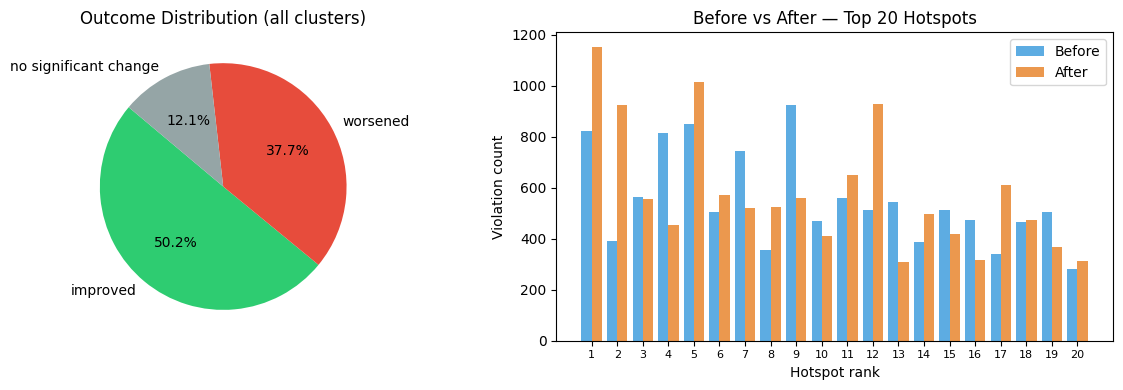

Chart saved to: ./enforcement_outcome_chart.png


In [7]:
"""
ENFORCEMENT OUTCOME TRACKING / BEFORE-AFTER FEEDBACK LOOP (Stage 3b)
=====================================================================
Colab-compatible version. Run this script cell-by-cell in a Colab notebook
by pasting sections, or execute top-to-bottom as a plain Python script.

Usage modes
-----------
Mode A — two separate files:
    Set INPUT_MODE = "A" and fill BEFORE_FILENAME / AFTER_FILENAME.

Mode B — single file split by date:
    Set INPUT_MODE = "B" and fill SINGLE_VIOLATIONS_FILENAME / SPLIT_DATE.

Steps performed
---------------
1. Install / import dependencies
2. Mount Google Drive (or upload files directly)
3. Validate file paths
4. (Mode B only) Split single violations CSV by date
5. Run synthetic self-test
6. Run the real enforcement outcome analysis
7. Save output CSV + optional chart PNG
"""

# ============================================================================
# STEP 1 — Install dependencies
# ============================================================================
# Uncomment the line below when running in Colab (tqdm is usually pre-installed
# but re-running pip install is safe).
# import subprocess; subprocess.run(["pip", "install", "tqdm", "--quiet"], check=True)

import pandas as pd
import numpy as np
import os

try:
    from tqdm.notebook import tqdm   # rich inline bar in Colab / Jupyter
except ImportError:
    from tqdm import tqdm            # plain-text fallback for script mode

print("✅ Imports complete.")


# ============================================================================
# STEP 2 — Google Drive mount  (Colab only)
# ============================================================================
# Option A: mount Drive
# ---------------------
# from google.colab import drive
# drive.mount('/content/drive')
# DRIVE_FOLDER = "/content/drive/MyDrive/"   # <-- change to your folder

# Option B: upload files directly
# --------------------------------
# from google.colab import files
# print("Upload your CSV files (hold Ctrl/Cmd to select multiple):")
# uploaded = files.upload()
# DRIVE_FOLDER = "/content/"

# Fallback for plain script execution (files expected in current directory)
DRIVE_FOLDER = "./"


# ============================================================================
# STEP 3 — File paths and configuration   ← EDIT THIS SECTION
# ============================================================================

INPUT_MODE = "B"   # "A" = two separate files | "B" = single file split by date

# ── Mode A ───────────────────────────────────────────────────────────────────
BEFORE_FILENAME = "violations_scored.csv"   # <-- change to your actual file name
AFTER_FILENAME  = "violations_after.csv"    # <-- change to your actual file name

# ── Mode B ───────────────────────────────────────────────────────────────────
SINGLE_VIOLATIONS_FILENAME = "violations_scored.csv"   # <-- change if needed
SPLIT_DATE = "2024-02-01"    # Enforcement start date (YYYY-MM-DD)

# ── Always required ──────────────────────────────────────────────────────────
HOTSPOTS_FILENAME = "hotspots.csv"              # <-- change if needed
OUTPUT_FILENAME   = "enforcement_outcome_report.csv"

# ── Analysis parameters ──────────────────────────────────────────────────────
IMPROVEMENT_THRESHOLD = 0.20   # ±20% boundary for improved / worsened
TOP_N_SUMMARY         = 20     # hotspots to include in printed summary

# ── Build full paths ─────────────────────────────────────────────────────────
HOTSPOTS_PATH = os.path.join(DRIVE_FOLDER, HOTSPOTS_FILENAME)
OUTPUT_PATH   = os.path.join(DRIVE_FOLDER, OUTPUT_FILENAME)

if INPUT_MODE == "A":
    BEFORE_PATH = os.path.join(DRIVE_FOLDER, BEFORE_FILENAME)
    AFTER_PATH  = os.path.join(DRIVE_FOLDER, AFTER_FILENAME)
else:
    SINGLE_PATH = os.path.join(DRIVE_FOLDER, SINGLE_VIOLATIONS_FILENAME)
    BEFORE_PATH = "/content/violations_before_split.csv"
    AFTER_PATH  = "/content/violations_after_split.csv"


def _verify_paths():
    """Raise a clear FileNotFoundError if any required input is missing."""
    to_check = [HOTSPOTS_PATH]
    if INPUT_MODE == "A":
        to_check += [BEFORE_PATH, AFTER_PATH]
    else:
        to_check += [SINGLE_PATH]

    for p in to_check:
        if not os.path.exists(p):
            raise FileNotFoundError(
                f"File not found: '{p}'\n"
                "→ Check DRIVE_FOLDER and the filename variables in STEP 3."
            )
    print("✅ All input files found.")


# ============================================================================
# STEP 4 — Date-split helper  (Mode B only)
# ============================================================================

def split_violations_by_date(violations_path, split_date,
                              before_output, after_output):
    """
    Split a single violations_scored CSV into two time-period files.
    Only loads the three columns needed for the analysis.
    """
    print(f"Splitting '{violations_path}' at {split_date} …")

    df = pd.read_csv(
        violations_path,
        usecols=["cluster_id", "violation_impact", "created_datetime"]
    )

    df["created_datetime"] = pd.to_datetime(df["created_datetime"], utc=True)
    split_dt = pd.to_datetime(split_date, utc=True)

    before = df[df["created_datetime"] <  split_dt][["cluster_id", "violation_impact"]]
    after  = df[df["created_datetime"] >= split_dt][["cluster_id", "violation_impact"]]

    before.to_csv(before_output, index=False)
    after.to_csv(after_output,  index=False)

    print(f"  Before (<{split_date}) : {len(before):,} violations → {before_output}")
    print(f"  After  (≥{split_date}) : {len(after):,}  violations → {after_output}")
    return len(before), len(after)


# ============================================================================
# STEP 5 — Core analysis function
# ============================================================================

def compute_enforcement_outcomes(
    violations_before_path,
    violations_after_path,
    hotspots_path,
    output_path,
    improvement_threshold=0.20,
    top_n_summary=20,
):
    """
    Compare two violation snapshots and compute per-hotspot outcome metrics.

    Returns
    -------
    pd.DataFrame — the full outcome report
    """
    print("=" * 60)
    print("ENFORCEMENT OUTCOME TRACKING")
    print("Before-After Feedback Loop Analysis")
    print("=" * 60)

    # ── Load data ─────────────────────────────────────────────────────────────
    print("\nLoading data…")
    needed = ["cluster_id", "violation_impact"]

    def _load_violations(path):
        try:
            return pd.read_csv(path, usecols=needed)
        except ValueError:
            df = pd.read_csv(path)
            missing = [c for c in needed if c not in df.columns]
            if missing:
                raise ValueError(
                    f"Missing columns {missing} in '{path}'.\n"
                    f"Available: {list(df.columns)}"
                )
            return df[needed]

    viol_before = _load_violations(violations_before_path)
    viol_after  = _load_violations(violations_after_path)
    hotspots    = pd.read_csv(hotspots_path)

    print(f"  Before period : {len(viol_before):,} violation records")
    print(f"  After period  : {len(viol_after):,} violation records")
    print(f"  Hotspots      : {len(hotspots):,} clusters")

    # ── Drop noise (cluster_id == -1 = unassigned) ───────────────────────────
    viol_before = viol_before[viol_before["cluster_id"] != -1].copy()
    viol_after  = viol_after[viol_after["cluster_id"] != -1].copy()
    print(f"  After noise filter: {len(viol_before):,} before, {len(viol_after):,} after")

    # ── Aggregate per cluster_id ──────────────────────────────────────────────
    before_agg = viol_before.groupby("cluster_id").agg(
        violation_count_before=("cluster_id", "count"),
        impact_before=("violation_impact", "sum"),
    ).reset_index()

    after_agg = viol_after.groupby("cluster_id").agg(
        violation_count_after=("cluster_id", "count"),
        impact_after=("violation_impact", "sum"),
    ).reset_index()

    # ── Merge with hotspot metadata ───────────────────────────────────────────
    meta_cols = ["cluster_id", "rank", "top_police_station",
                 "top_junction", "hotspot_impact_score"]
    hotspot_meta = hotspots[[c for c in meta_cols if c in hotspots.columns]].copy()
    hotspot_meta.rename(columns={
        "top_police_station": "police_station",
        "top_junction": "junction",
    }, inplace=True)

    merged = hotspot_meta.merge(before_agg, on="cluster_id", how="outer")
    merged = merged.merge(after_agg,  on="cluster_id", how="outer")

    merged["violation_count_before"] = merged["violation_count_before"].fillna(0).astype(int)
    merged["violation_count_after"]  = merged["violation_count_after"].fillna(0).astype(int)
    merged["impact_before"]          = merged["impact_before"].fillna(0.0)
    merged["impact_after"]           = merged["impact_after"].fillna(0.0)

    # ── Compute metrics ───────────────────────────────────────────────────────
    def safe_pct_change(before, after):
        if before == 0 and after == 0:
            return 0.0
        elif before == 0:
            return 1.0   # 100% increase — new violations appeared
        return (after - before) / before

    tqdm.pandas(desc="Computing % change")
    merged["percent_change"] = merged.progress_apply(
        lambda r: safe_pct_change(r["violation_count_before"], r["violation_count_after"]),
        axis=1,
    )
    merged["impact_percent_change"] = merged.apply(
        lambda r: safe_pct_change(r["impact_before"], r["impact_after"]),
        axis=1,
    )

    def classify_outcome(pct_change, count_before, count_after):
        if count_before == 0 and count_after == 0:
            return "no significant change"
        elif pct_change <= -improvement_threshold:
            return "improved"
        elif pct_change >= improvement_threshold:
            return "worsened"
        return "no significant change"

    merged["outcome_flag"] = merged.apply(
        lambda r: classify_outcome(
            r["percent_change"],
            r["violation_count_before"],
            r["violation_count_after"],
        ),
        axis=1,
    )

    # Round for readability
    merged["percent_change"]        = (merged["percent_change"] * 100).round(1)
    merged["impact_percent_change"] = (merged["impact_percent_change"] * 100).round(1)
    merged["impact_before"]         = merged["impact_before"].round(2)
    merged["impact_after"]          = merged["impact_after"].round(2)

    merged["rank"] = merged["rank"].fillna(9999).astype(int)
    merged = merged.sort_values("rank").reset_index(drop=True)

    # ── Save output ───────────────────────────────────────────────────────────
    output_cols = [
        "cluster_id", "rank", "police_station", "junction",
        "violation_count_before", "violation_count_after",
        "percent_change", "outcome_flag",
        "impact_before", "impact_after", "impact_percent_change",
        "hotspot_impact_score",
    ]
    report = merged[[c for c in output_cols if c in merged.columns]].copy()
    report.to_csv(output_path, index=False)

    # ── Print summary ─────────────────────────────────────────────────────────
    print(f"\n{'=' * 60}")
    print(f"OUTPUT saved to: {output_path}")
    print(f"{'=' * 60}")

    total     = len(report)
    improved  = (report["outcome_flag"] == "improved").sum()
    worsened  = (report["outcome_flag"] == "worsened").sum()
    unchanged = (report["outcome_flag"] == "no significant change").sum()

    print(f"\nOVERALL SUMMARY ({total} clusters analysed):")
    print(f"  ✅ Improved  (≥{improvement_threshold*100:.0f}% decrease) : {improved:,}")
    print(f"  ❌ Worsened  (≥{improvement_threshold*100:.0f}% increase) : {worsened:,}")
    print(f"  ➖ No significant change (±{improvement_threshold*100:.0f}%) : {unchanged:,}")

    top_n = report[report["rank"] <= top_n_summary]
    if len(top_n) > 0:
        print(f"\nTOP {top_n_summary} HOTSPOTS:")
        print(f"{'Rank':>5} {'Cluster':>8} {'Before':>8} {'After':>8} "
              f"{'%Change':>9} {'Outcome':>22} {'Station':>20}")
        print("-" * 85)
        for _, r in top_n.iterrows():
            station = str(r.get("police_station", "N/A"))[:20]
            print(f"{int(r['rank']):>5} {int(r['cluster_id']):>8} "
                  f"{int(r['violation_count_before']):>8} {int(r['violation_count_after']):>8} "
                  f"{r['percent_change']:>8.1f}% {r['outcome_flag']:>22} {station:>20}")

    total_ib = report["impact_before"].sum()
    total_ia = report["impact_after"].sum()
    if total_ib > 0:
        chg = (total_ia - total_ib) / total_ib * 100
        print(f"\nAGGREGATE IMPACT:")
        print(f"  Before: {total_ib:,.1f}")
        print(f"  After : {total_ia:,.1f}")
        print(f"  Change: {chg:+.1f}%")

    return report


# ============================================================================
# STEP 6 — Synthetic self-test
# ============================================================================

def run_synthetic_test():
    """
    Run a controlled 6-cluster test with known expected outcomes.
    All assertions must pass before running on real data.
    """
    print("\n" + "=" * 60)
    print("SYNTHETIC TEST — Enforcement Outcome Tracking")
    print("=" * 60)

    hotspots_data = pd.DataFrame({
        "cluster_id":           [101, 102, 103, 104, 105, 106],
        "violation_count":      [100,  80,  60,  40,  20,  10],
        "avg_lat":              [12.97, 12.96, 12.95, 12.94, 12.93, 12.92],
        "avg_lon":              [77.59, 77.58, 77.57, 77.56, 77.55, 77.54],
        "total_impact":         [200, 160, 120, 80, 40, 20],
        "avg_impact":           [2.0] * 6,
        "top_police_station":   ["StationA","StationB","StationC","StationD","StationE","StationF"],
        "top_junction":         ["Jn1","Jn2","Jn3","Jn4","Jn5","Jn6"],
        "date_span_days":       [30] * 6,
        "unique_days":          [25, 20, 15, 10, 5, 3],
        "dominant_violation":   ["NO PARKING"] * 6,
        "recurrence_rate":      [0.83, 0.67, 0.50, 0.33, 0.17, 0.10],
        "hotspot_impact_score": [180, 130, 90, 60, 30, 15],
        "rank":                 [1, 2, 3, 4, 5, 6],
    })

    np.random.seed(42)

    # Designed outcomes:
    # 101: 50 → 30  (-40%) → IMPROVED ✅
    # 102: 40 → 38  (-5%)  → NO CHANGE ➖
    # 103: 30 → 45  (+50%) → WORSENED ❌
    # 104: 20 → 0   (-100%)→ IMPROVED ✅
    # 105: 10 → 11  (+10%) → NO CHANGE ➖
    # 106:  0 → 15  (new)  → WORSENED ❌
    before_counts = {101: 50, 102: 40, 103: 30, 104: 20, 105: 10}
    after_counts  = {101: 30, 102: 38, 103: 45, 105: 11, 106: 15}

    def _make_records(counts):
        return [
            {"cluster_id": cid,
             "violation_impact": round(np.random.uniform(0.5, 3.0), 2)}
            for cid, n in counts.items() for _ in range(n)
        ]

    # Use /content/ in Colab, otherwise current dir
    scratch = "/content/" if os.path.isdir("/content/") else "./"
    TEST_HS  = os.path.join(scratch, "test_hotspots_enforcement.csv")
    TEST_BEF = os.path.join(scratch, "test_violations_before.csv")
    TEST_AFT = os.path.join(scratch, "test_violations_after.csv")
    TEST_OUT = os.path.join(scratch, "test_enforcement_outcome.csv")

    hotspots_data.to_csv(TEST_HS, index=False)
    pd.DataFrame(_make_records(before_counts)).to_csv(TEST_BEF, index=False)
    pd.DataFrame(_make_records(after_counts)).to_csv(TEST_AFT,  index=False)

    print("\nExpected outcomes:")
    expected = {
        101: "improved",
        102: "no significant change",
        103: "worsened",
        104: "improved",
        105: "no significant change",
        106: "worsened",
    }
    for cid, out in expected.items():
        print(f"  Cluster {cid}: {out}")

    report = compute_enforcement_outcomes(
        violations_before_path=TEST_BEF,
        violations_after_path=TEST_AFT,
        hotspots_path=TEST_HS,
        output_path=TEST_OUT,
        improvement_threshold=0.20,
        top_n_summary=6,
    )

    print(f"\n{'=' * 60}")
    print("VALIDATION")
    print(f"{'=' * 60}")

    all_passed = True
    for cid, exp in expected.items():
        row = report[report["cluster_id"] == cid]
        if row.empty:
            print(f"  ❌ Cluster {cid}: NOT FOUND in report")
            all_passed = False
            continue
        actual = row.iloc[0]["outcome_flag"]
        icon   = "✅" if actual == exp else "❌"
        if actual != exp:
            all_passed = False
        print(f"  {icon} Cluster {cid}: expected='{exp}', got='{actual}'")

    if all_passed:
        print("\n✅ All assertions passed!")
    else:
        print("\n❌ Some assertions FAILED — review the logic above.")

    for f in [TEST_HS, TEST_BEF, TEST_AFT]:
        os.remove(f)
    print(f"✅ Test inputs removed. Output preserved: {TEST_OUT}")
    return report


# ============================================================================
# STEP 7 — Optional chart
# ============================================================================

def save_outcome_chart(report, output_dir=None):
    """
    Save a two-panel PNG: outcome pie chart + before/after bar chart (top 20).
    Requires matplotlib (pre-installed in Colab).
    """
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib not available — skipping chart.")
        return

    if output_dir is None:
        output_dir = DRIVE_FOLDER

    colors = {
        "improved":              "#2ecc71",
        "worsened":              "#e74c3c",
        "no significant change": "#95a5a6",
    }

    counts = report["outcome_flag"].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].pie(
        counts.values,
        labels=counts.index,
        colors=[colors.get(k, "#bdc3c7") for k in counts.index],
        autopct="%1.1f%%",
        startangle=140,
    )
    axes[0].set_title("Outcome Distribution (all clusters)")

    top20 = report[report["rank"] <= 20].copy()
    x = range(len(top20))
    axes[1].bar([i - 0.2 for i in x], top20["violation_count_before"],
                width=0.4, label="Before", color="#3498db", alpha=0.8)
    axes[1].bar([i + 0.2 for i in x], top20["violation_count_after"],
                width=0.4, label="After",  color="#e67e22", alpha=0.8)
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(top20["rank"].astype(str), fontsize=8)
    axes[1].set_xlabel("Hotspot rank")
    axes[1].set_ylabel("Violation count")
    axes[1].set_title("Before vs After — Top 20 Hotspots")
    axes[1].legend()

    plt.tight_layout()
    chart_path = os.path.join(output_dir, "enforcement_outcome_chart.png")
    plt.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Chart saved to: {chart_path}")


# ============================================================================
# STEP 8 — Download output (Colab only, when files were uploaded directly)
# ============================================================================

def download_output(path):
    """
    Trigger a browser download of the output CSV.
    Only works inside Google Colab; silently skips in plain Python.
    """
    try:
        from google.colab import files
        files.download(path)
        print(f"Download triggered for: {path}")
    except ImportError:
        print(f"Not running in Colab — file is at: {path}")


# ============================================================================
# MAIN
# ============================================================================

if __name__ == "__main__":
    # ── 1. Validate paths ─────────────────────────────────────────────────────
    _verify_paths()

    # ── 2. Mode B: split by date ──────────────────────────────────────────────
    if INPUT_MODE == "B":
        split_violations_by_date(SINGLE_PATH, SPLIT_DATE, BEFORE_PATH, AFTER_PATH)

    # ── 3. Synthetic self-test ────────────────────────────────────────────────
    run_synthetic_test()

    # ── 4. Real analysis ──────────────────────────────────────────────────────
    print("\n\n")
    df_report = compute_enforcement_outcomes(
        violations_before_path=BEFORE_PATH,
        violations_after_path=AFTER_PATH,
        hotspots_path=HOTSPOTS_PATH,
        output_path=OUTPUT_PATH,
        improvement_threshold=IMPROVEMENT_THRESHOLD,
        top_n_summary=TOP_N_SUMMARY,
    )

    # ── 5. Save chart ─────────────────────────────────────────────────────────
    save_outcome_chart(df_report)

    # ── 6. Download (Colab only) ──────────────────────────────────────────────
    # Uncomment the line below if you uploaded files directly (not via Drive):
    # download_output(OUTPUT_PATH)

✅ Imports complete.
✅ All input files found.
Splitting './violations_scored.csv' at 2024-02-01 …
  Before (<2024-02-01) : 132,471 violations → /content/violations_before_split.csv
  After  (≥2024-02-01) : 116,220  violations → /content/violations_after_split.csv

SYNTHETIC TEST — Enforcement Outcome Tracking

Expected outcomes:
  Cluster 101: improved
  Cluster 102: no significant change
  Cluster 103: worsened
  Cluster 104: improved
  Cluster 105: no significant change
  Cluster 106: worsened
ENFORCEMENT OUTCOME TRACKING
Before-After Feedback Loop Analysis

Loading data…
  Before period : 150 violation records
  After period  : 139 violation records
  Hotspots      : 6 clusters
  After noise filter: 150 before, 139 after


Computing % change:   0%|          | 0/6 [00:00<?, ?it/s]


OUTPUT saved to: /content/test_enforcement_outcome.csv

OVERALL SUMMARY (6 clusters analysed):
  ✅ Improved  (≥20% decrease) : 2
  ❌ Worsened  (≥20% increase) : 2
  ➖ No significant change (±20%) : 2

TOP 6 HOTSPOTS:
 Rank  Cluster   Before    After   %Change                Outcome              Station
-------------------------------------------------------------------------------------
    1      101       50       30    -40.0%               improved             StationA
    2      102       40       38     -5.0%  no significant change             StationB
    3      103       30       45     50.0%               worsened             StationC
    4      104       20        0   -100.0%               improved             StationD
    5      105       10       11     10.0%  no significant change             StationE
    6      106        0       15    100.0%               worsened             StationF

AGGREGATE IMPACT:
  Before: 252.4
  After : 253.0
  Change: +0.3%

VALIDATION
  ✅ Clus

Computing % change:   0%|          | 0/4814 [00:00<?, ?it/s]


OUTPUT saved to: ./enforcement_outcome_report.csv

OVERALL SUMMARY (4814 clusters analysed):
  ✅ Improved  (≥20% decrease) : 2,415
  ❌ Worsened  (≥20% increase) : 1,817
  ➖ No significant change (±20%) : 582

TOP 20 HOTSPOTS:
 Rank  Cluster   Before    After   %Change                Outcome              Station
-------------------------------------------------------------------------------------
    1     7374      824     1152     39.8%               worsened         Shivajinagar
    2     5067      392      923    135.5%               worsened          City Market
    3     3188      564      555     -1.6%  no significant change      HAL Old Airport
    4     7708      813      453    -44.3%               improved         Shivajinagar
    5     2727      851     1013     19.0%  no significant change      HAL Old Airport
    6     5135      503      573     13.9%  no significant change          City Market
    7     7356      745      522    -29.9%               improved         Shiv

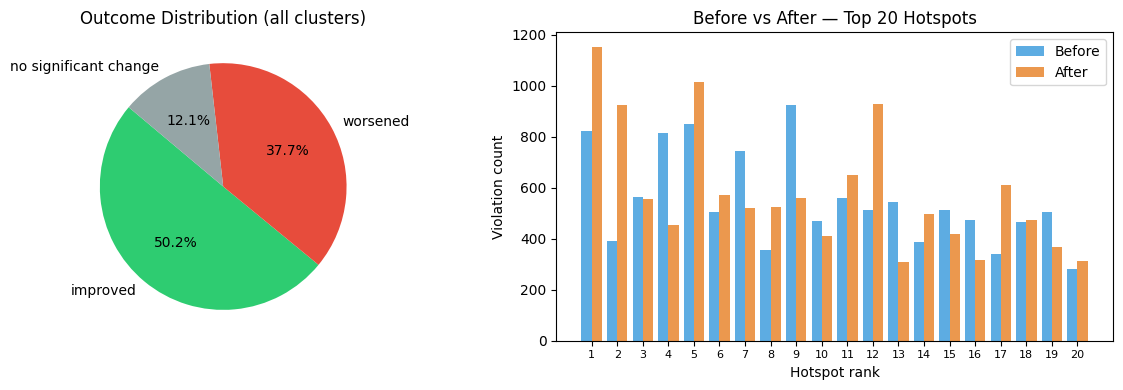

Chart saved to: ./enforcement_outcome_chart.png


In [8]:
"""
ENFORCEMENT OUTCOME TRACKING / BEFORE-AFTER FEEDBACK LOOP (Stage 3b)
=====================================================================
Colab-compatible version. Run this script cell-by-cell in a Colab notebook
by pasting sections, or execute top-to-bottom as a plain Python script.

Usage modes
-----------
Mode A — two separate files:
    Set INPUT_MODE = "A" and fill BEFORE_FILENAME / AFTER_FILENAME.

Mode B — single file split by date:
    Set INPUT_MODE = "B" and fill SINGLE_VIOLATIONS_FILENAME / SPLIT_DATE.

Steps performed
---------------
1. Install / import dependencies
2. Mount Google Drive (or upload files directly)
3. Validate file paths
4. (Mode B only) Split single violations CSV by date
5. Run synthetic self-test
6. Run the real enforcement outcome analysis
7. Save output CSV + optional chart PNG
"""

# ============================================================================
# STEP 1 — Install dependencies
# ============================================================================
# Uncomment the line below when running in Colab (tqdm is usually pre-installed
# but re-running pip install is safe).
# import subprocess; subprocess.run(["pip", "install", "tqdm", "--quiet"], check=True)

import pandas as pd
import numpy as np
import os

try:
    from tqdm.notebook import tqdm   # rich inline bar in Colab / Jupyter
except ImportError:
    from tqdm import tqdm            # plain-text fallback for script mode

print("✅ Imports complete.")


# ============================================================================
# STEP 2 — Google Drive mount  (Colab only)
# ============================================================================
# Option A: mount Drive
# ---------------------
# from google.colab import drive
# drive.mount('/content/drive')
# DRIVE_FOLDER = "/content/drive/MyDrive/"   # <-- change to your folder

# Option B: upload files directly
# --------------------------------
# from google.colab import files
# print("Upload your CSV files (hold Ctrl/Cmd to select multiple):")
# uploaded = files.upload()
# DRIVE_FOLDER = "/content/"

# Fallback for plain script execution (files expected in current directory)
DRIVE_FOLDER = "./"


# ============================================================================
# STEP 3 — File paths and configuration   ← EDIT THIS SECTION
# ============================================================================

INPUT_MODE = "B"   # "A" = two separate files | "B" = single file split by date

# ── Mode A ───────────────────────────────────────────────────────────────────
BEFORE_FILENAME = "violations_scored.csv"   # <-- change to your actual file name
AFTER_FILENAME  = "violations_after.csv"    # <-- change to your actual file name

# ── Mode B ───────────────────────────────────────────────────────────────────
SINGLE_VIOLATIONS_FILENAME = "violations_scored.csv"   # <-- change if needed
SPLIT_DATE = "2024-02-01"    # Enforcement start date (YYYY-MM-DD)

# ── Always required ──────────────────────────────────────────────────────────
HOTSPOTS_FILENAME = "hotspots.csv"              # <-- change if needed
OUTPUT_FILENAME   = "enforcement_outcome_report.csv"

# ── Analysis parameters ──────────────────────────────────────────────────────
IMPROVEMENT_THRESHOLD = 0.20   # ±20% boundary for improved / worsened
TOP_N_SUMMARY         = 20     # hotspots to include in printed summary

# ── Build full paths ─────────────────────────────────────────────────────────
HOTSPOTS_PATH = os.path.join(DRIVE_FOLDER, HOTSPOTS_FILENAME)
OUTPUT_PATH   = os.path.join(DRIVE_FOLDER, OUTPUT_FILENAME)

if INPUT_MODE == "A":
    BEFORE_PATH = os.path.join(DRIVE_FOLDER, BEFORE_FILENAME)
    AFTER_PATH  = os.path.join(DRIVE_FOLDER, AFTER_FILENAME)
else:
    SINGLE_PATH = os.path.join(DRIVE_FOLDER, SINGLE_VIOLATIONS_FILENAME)
    BEFORE_PATH = "/content/violations_before_split.csv"
    AFTER_PATH  = "/content/violations_after_split.csv"


def _verify_paths():
    """Raise a clear FileNotFoundError if any required input is missing."""
    to_check = [HOTSPOTS_PATH]
    if INPUT_MODE == "A":
        to_check += [BEFORE_PATH, AFTER_PATH]
    else:
        to_check += [SINGLE_PATH]

    for p in to_check:
        if not os.path.exists(p):
            raise FileNotFoundError(
                f"File not found: '{p}'\n"
                "→ Check DRIVE_FOLDER and the filename variables in STEP 3."
            )
    print("✅ All input files found.")


# ============================================================================
# STEP 4 — Date-split helper  (Mode B only)
# ============================================================================

def split_violations_by_date(violations_path, split_date,
                              before_output, after_output):
    """
    Split a single violations_scored CSV into two time-period files.
    Only loads the three columns needed for the analysis.
    """
    print(f"Splitting '{violations_path}' at {split_date} …")

    df = pd.read_csv(
        violations_path,
        usecols=["cluster_id", "violation_impact", "created_datetime"]
    )

    df["created_datetime"] = pd.to_datetime(df["created_datetime"], utc=True)
    split_dt = pd.to_datetime(split_date, utc=True)

    before = df[df["created_datetime"] <  split_dt][["cluster_id", "violation_impact"]]
    after  = df[df["created_datetime"] >= split_dt][["cluster_id", "violation_impact"]]

    before.to_csv(before_output, index=False)
    after.to_csv(after_output,  index=False)

    print(f"  Before (<{split_date}) : {len(before):,} violations → {before_output}")
    print(f"  After  (≥{split_date}) : {len(after):,}  violations → {after_output}")
    return len(before), len(after)


# ============================================================================
# STEP 5 — Core analysis function
# ============================================================================

def compute_enforcement_outcomes(
    violations_before_path,
    violations_after_path,
    hotspots_path,
    output_path,
    improvement_threshold=0.20,
    top_n_summary=20,
):
    """
    Compare two violation snapshots and compute per-hotspot outcome metrics.

    Returns
    -------
    pd.DataFrame — the full outcome report
    """
    print("=" * 60)
    print("ENFORCEMENT OUTCOME TRACKING")
    print("Before-After Feedback Loop Analysis")
    print("=" * 60)

    # ── Load data ─────────────────────────────────────────────────────────────
    print("\nLoading data…")
    needed = ["cluster_id", "violation_impact"]

    def _load_violations(path):
        try:
            return pd.read_csv(path, usecols=needed)
        except ValueError:
            df = pd.read_csv(path)
            missing = [c for c in needed if c not in df.columns]
            if missing:
                raise ValueError(
                    f"Missing columns {missing} in '{path}'.\n"
                    f"Available: {list(df.columns)}"
                )
            return df[needed]

    viol_before = _load_violations(violations_before_path)
    viol_after  = _load_violations(violations_after_path)
    hotspots    = pd.read_csv(hotspots_path)

    print(f"  Before period : {len(viol_before):,} violation records")
    print(f"  After period  : {len(viol_after):,} violation records")
    print(f"  Hotspots      : {len(hotspots):,} clusters")

    # ── Drop noise (cluster_id == -1 = unassigned) ───────────────────────────
    viol_before = viol_before[viol_before["cluster_id"] != -1].copy()
    viol_after  = viol_after[viol_after["cluster_id"] != -1].copy()
    print(f"  After noise filter: {len(viol_before):,} before, {len(viol_after):,} after")

    # ── Aggregate per cluster_id ──────────────────────────────────────────────
    before_agg = viol_before.groupby("cluster_id").agg(
        violation_count_before=("cluster_id", "count"),
        impact_before=("violation_impact", "sum"),
    ).reset_index()

    after_agg = viol_after.groupby("cluster_id").agg(
        violation_count_after=("cluster_id", "count"),
        impact_after=("violation_impact", "sum"),
    ).reset_index()

    # ── Merge with hotspot metadata ───────────────────────────────────────────
    meta_cols = ["cluster_id", "rank", "top_police_station",
                 "top_junction", "hotspot_impact_score"]
    hotspot_meta = hotspots[[c for c in meta_cols if c in hotspots.columns]].copy()
    hotspot_meta.rename(columns={
        "top_police_station": "police_station",
        "top_junction": "junction",
    }, inplace=True)

    merged = hotspot_meta.merge(before_agg, on="cluster_id", how="outer")
    merged = merged.merge(after_agg,  on="cluster_id", how="outer")

    merged["violation_count_before"] = merged["violation_count_before"].fillna(0).astype(int)
    merged["violation_count_after"]  = merged["violation_count_after"].fillna(0).astype(int)
    merged["impact_before"]          = merged["impact_before"].fillna(0.0)
    merged["impact_after"]           = merged["impact_after"].fillna(0.0)

    # ── Compute metrics ───────────────────────────────────────────────────────
    def safe_pct_change(before, after):
        if before == 0 and after == 0:
            return 0.0
        elif before == 0:
            return 1.0   # 100% increase — new violations appeared
        return (after - before) / before

    tqdm.pandas(desc="Computing % change")
    merged["percent_change"] = merged.progress_apply(
        lambda r: safe_pct_change(r["violation_count_before"], r["violation_count_after"]),
        axis=1,
    )
    merged["impact_percent_change"] = merged.apply(
        lambda r: safe_pct_change(r["impact_before"], r["impact_after"]),
        axis=1,
    )

    def classify_outcome(pct_change, count_before, count_after):
        if count_before == 0 and count_after == 0:
            return "no significant change"
        elif pct_change <= -improvement_threshold:
            return "improved"
        elif pct_change >= improvement_threshold:
            return "worsened"
        return "no significant change"

    merged["outcome_flag"] = merged.apply(
        lambda r: classify_outcome(
            r["percent_change"],
            r["violation_count_before"],
            r["violation_count_after"],
        ),
        axis=1,
    )

    # Round for readability
    merged["percent_change"]        = (merged["percent_change"] * 100).round(1)
    merged["impact_percent_change"] = (merged["impact_percent_change"] * 100).round(1)
    merged["impact_before"]         = merged["impact_before"].round(2)
    merged["impact_after"]          = merged["impact_after"].round(2)

    merged["rank"] = merged["rank"].fillna(9999).astype(int)
    merged = merged.sort_values("rank").reset_index(drop=True)

    # ── Save output ───────────────────────────────────────────────────────────
    output_cols = [
        "cluster_id", "rank", "police_station", "junction",
        "violation_count_before", "violation_count_after",
        "percent_change", "outcome_flag",
        "impact_before", "impact_after", "impact_percent_change",
        "hotspot_impact_score",
    ]
    report = merged[[c for c in output_cols if c in merged.columns]].copy()
    report.to_csv(output_path, index=False)

    # ── Print summary ─────────────────────────────────────────────────────────
    print(f"\n{'=' * 60}")
    print(f"OUTPUT saved to: {output_path}")
    print(f"{'=' * 60}")

    total     = len(report)
    improved  = (report["outcome_flag"] == "improved").sum()
    worsened  = (report["outcome_flag"] == "worsened").sum()
    unchanged = (report["outcome_flag"] == "no significant change").sum()

    print(f"\nOVERALL SUMMARY ({total} clusters analysed):")
    print(f"  ✅ Improved  (≥{improvement_threshold*100:.0f}% decrease) : {improved:,}")
    print(f"  ❌ Worsened  (≥{improvement_threshold*100:.0f}% increase) : {worsened:,}")
    print(f"  ➖ No significant change (±{improvement_threshold*100:.0f}%) : {unchanged:,}")

    top_n = report[report["rank"] <= top_n_summary]
    if len(top_n) > 0:
        print(f"\nTOP {top_n_summary} HOTSPOTS:")
        print(f"{'Rank':>5} {'Cluster':>8} {'Before':>8} {'After':>8} "
              f"{'%Change':>9} {'Outcome':>22} {'Station':>20}")
        print("-" * 85)
        for _, r in top_n.iterrows():
            station = str(r.get("police_station", "N/A"))[:20]
            print(f"{int(r['rank']):>5} {int(r['cluster_id']):>8} "
                  f"{int(r['violation_count_before']):>8} {int(r['violation_count_after']):>8} "
                  f"{r['percent_change']:>8.1f}% {r['outcome_flag']:>22} {station:>20}")

    total_ib = report["impact_before"].sum()
    total_ia = report["impact_after"].sum()
    if total_ib > 0:
        chg = (total_ia - total_ib) / total_ib * 100
        print(f"\nAGGREGATE IMPACT:")
        print(f"  Before: {total_ib:,.1f}")
        print(f"  After : {total_ia:,.1f}")
        print(f"  Change: {chg:+.1f}%")

    return report


# ============================================================================
# STEP 6 — Synthetic self-test
# ============================================================================

def run_synthetic_test():
    """
    Run a controlled 6-cluster test with known expected outcomes.
    All assertions must pass before running on real data.
    """
    print("\n" + "=" * 60)
    print("SYNTHETIC TEST — Enforcement Outcome Tracking")
    print("=" * 60)

    hotspots_data = pd.DataFrame({
        "cluster_id":           [101, 102, 103, 104, 105, 106],
        "violation_count":      [100,  80,  60,  40,  20,  10],
        "avg_lat":              [12.97, 12.96, 12.95, 12.94, 12.93, 12.92],
        "avg_lon":              [77.59, 77.58, 77.57, 77.56, 77.55, 77.54],
        "total_impact":         [200, 160, 120, 80, 40, 20],
        "avg_impact":           [2.0] * 6,
        "top_police_station":   ["StationA","StationB","StationC","StationD","StationE","StationF"],
        "top_junction":         ["Jn1","Jn2","Jn3","Jn4","Jn5","Jn6"],
        "date_span_days":       [30] * 6,
        "unique_days":          [25, 20, 15, 10, 5, 3],
        "dominant_violation":   ["NO PARKING"] * 6,
        "recurrence_rate":      [0.83, 0.67, 0.50, 0.33, 0.17, 0.10],
        "hotspot_impact_score": [180, 130, 90, 60, 30, 15],
        "rank":                 [1, 2, 3, 4, 5, 6],
    })

    np.random.seed(42)

    # Designed outcomes:
    # 101: 50 → 30  (-40%) → IMPROVED ✅
    # 102: 40 → 38  (-5%)  → NO CHANGE ➖
    # 103: 30 → 45  (+50%) → WORSENED ❌
    # 104: 20 → 0   (-100%)→ IMPROVED ✅
    # 105: 10 → 11  (+10%) → NO CHANGE ➖
    # 106:  0 → 15  (new)  → WORSENED ❌
    before_counts = {101: 50, 102: 40, 103: 30, 104: 20, 105: 10}
    after_counts  = {101: 30, 102: 38, 103: 45, 105: 11, 106: 15}

    def _make_records(counts):
        return [
            {"cluster_id": cid,
             "violation_impact": round(np.random.uniform(0.5, 3.0), 2)}
            for cid, n in counts.items() for _ in range(n)
        ]

    # Use /content/ in Colab, otherwise current dir
    scratch = "/content/" if os.path.isdir("/content/") else "./"
    TEST_HS  = os.path.join(scratch, "test_hotspots_enforcement.csv")
    TEST_BEF = os.path.join(scratch, "test_violations_before.csv")
    TEST_AFT = os.path.join(scratch, "test_violations_after.csv")
    TEST_OUT = os.path.join(scratch, "test_enforcement_outcome.csv")

    hotspots_data.to_csv(TEST_HS, index=False)
    pd.DataFrame(_make_records(before_counts)).to_csv(TEST_BEF, index=False)
    pd.DataFrame(_make_records(after_counts)).to_csv(TEST_AFT,  index=False)

    print("\nExpected outcomes:")
    expected = {
        101: "improved",
        102: "no significant change",
        103: "worsened",
        104: "improved",
        105: "no significant change",
        106: "worsened",
    }
    for cid, out in expected.items():
        print(f"  Cluster {cid}: {out}")

    report = compute_enforcement_outcomes(
        violations_before_path=TEST_BEF,
        violations_after_path=TEST_AFT,
        hotspots_path=TEST_HS,
        output_path=TEST_OUT,
        improvement_threshold=0.20,
        top_n_summary=6,
    )

    print(f"\n{'=' * 60}")
    print("VALIDATION")
    print(f"{'=' * 60}")

    all_passed = True
    for cid, exp in expected.items():
        row = report[report["cluster_id"] == cid]
        if row.empty:
            print(f"  ❌ Cluster {cid}: NOT FOUND in report")
            all_passed = False
            continue
        actual = row.iloc[0]["outcome_flag"]
        icon   = "✅" if actual == exp else "❌"
        if actual != exp:
            all_passed = False
        print(f"  {icon} Cluster {cid}: expected='{exp}', got='{actual}'")

    if all_passed:
        print("\n✅ All assertions passed!")
    else:
        print("\n❌ Some assertions FAILED — review the logic above.")

    for f in [TEST_HS, TEST_BEF, TEST_AFT]:
        os.remove(f)
    print(f"✅ Test inputs removed. Output preserved: {TEST_OUT}")
    return report


# ============================================================================
# STEP 7 — Optional chart
# ============================================================================

def save_outcome_chart(report, output_dir=None):
    """
    Save a two-panel PNG: outcome pie chart + before/after bar chart (top 20).
    Requires matplotlib (pre-installed in Colab).
    """
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib not available — skipping chart.")
        return

    if output_dir is None:
        output_dir = DRIVE_FOLDER

    colors = {
        "improved":              "#2ecc71",
        "worsened":              "#e74c3c",
        "no significant change": "#95a5a6",
    }

    counts = report["outcome_flag"].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].pie(
        counts.values,
        labels=counts.index,
        colors=[colors.get(k, "#bdc3c7") for k in counts.index],
        autopct="%1.1f%%",
        startangle=140,
    )
    axes[0].set_title("Outcome Distribution (all clusters)")

    top20 = report[report["rank"] <= 20].copy()
    x = range(len(top20))
    axes[1].bar([i - 0.2 for i in x], top20["violation_count_before"],
                width=0.4, label="Before", color="#3498db", alpha=0.8)
    axes[1].bar([i + 0.2 for i in x], top20["violation_count_after"],
                width=0.4, label="After",  color="#e67e22", alpha=0.8)
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(top20["rank"].astype(str), fontsize=8)
    axes[1].set_xlabel("Hotspot rank")
    axes[1].set_ylabel("Violation count")
    axes[1].set_title("Before vs After — Top 20 Hotspots")
    axes[1].legend()

    plt.tight_layout()
    chart_path = os.path.join(output_dir, "enforcement_outcome_chart.png")
    plt.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Chart saved to: {chart_path}")


# ============================================================================
# STEP 8 — Download output (Colab only, when files were uploaded directly)
# ============================================================================

def download_output(path):
    """
    Trigger a browser download of the output CSV.
    Only works inside Google Colab; silently skips in plain Python.
    """
    try:
        from google.colab import files
        files.download(path)
        print(f"Download triggered for: {path}")
    except ImportError:
        print(f"Not running in Colab — file is at: {path}")


# ============================================================================
# MAIN
# ============================================================================

if __name__ == "__main__":
    # ── 1. Validate paths ─────────────────────────────────────────────────────
    _verify_paths()

    # ── 2. Mode B: split by date ──────────────────────────────────────────────
    if INPUT_MODE == "B":
        split_violations_by_date(SINGLE_PATH, SPLIT_DATE, BEFORE_PATH, AFTER_PATH)

    # ── 3. Synthetic self-test ────────────────────────────────────────────────
    run_synthetic_test()

    # ── 4. Real analysis ──────────────────────────────────────────────────────
    print("\n\n")
    df_report = compute_enforcement_outcomes(
        violations_before_path=BEFORE_PATH,
        violations_after_path=AFTER_PATH,
        hotspots_path=HOTSPOTS_PATH,
        output_path=OUTPUT_PATH,
        improvement_threshold=IMPROVEMENT_THRESHOLD,
        top_n_summary=TOP_N_SUMMARY,
    )

    # ── 5. Save chart ─────────────────────────────────────────────────────────
    save_outcome_chart(df_report)

    # ── 6. Download (Colab only) ──────────────────────────────────────────────
    # Uncomment the line below if you uploaded files directly (not via Drive):
    # download_output(OUTPUT_PATH)

Imports complete.
Input  : ./hotspots.csv
Output : ./hotspots_with_road_context.csv
Road dataset: 80 segments (25 trunk, 36 primary, 19 secondary)
enrich_hotspots_with_road_context() defined.

SELF TEST
  [OK] MG Road area              -> primary      (MG Road, 0m, weight=2.0)
  [OK] ORR Marathahalli          -> trunk        (ORR East, 0m, weight=2.5)
  [OK] Mysore Road               -> trunk        (Mysore Road, 472m, weight=2.5)
  [OK] Koramangala               -> primary      (Koramangala 80ft Road, 0m, weight=2.0)
  [OK] Basavanagudi              -> primary      (Bull Temple Road, 541m, weight=2.0)

All tests passed.


ROAD-NETWORK IMPACT ENRICHMENT  (zero-API, embedded roads)
Loaded 4814 hotspots

Looking up nearest road for 4814 hotspots...


Road lookups:   0%|          | 0/4814 [00:00<?, ?it/s]


OUTPUT : ./hotspots_with_road_context.csv
Time   : 0.68s

Road Class Distribution:
  primary             :  1692  (weight=2.0)
  residential         :  1277  (weight=1.0)
  trunk               :   952  (weight=2.5)
  secondary           :   893  (weight=1.5)

Weight stats:
count    4814.000000
mean        1.740860
std         0.542208
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         2.500000

Top 10 by Score v2:
 Rank_v2  OldRank  Cluster   Score_v1  Weight   Score_v2            Road   Dist_m
----------------------------------------------------------------------------------
       1        1     7374     2390.5     1.5     3585.8       secondary     566m
       2        3     3188     1545.9     2.0     3091.9         primary     160m
       3        5     2727     1455.2     2.0     2910.4         primary      57m
       4        2     5067     1791.8     1.5     2687.6       secondary     501m
       5       20     9998      929.2     2

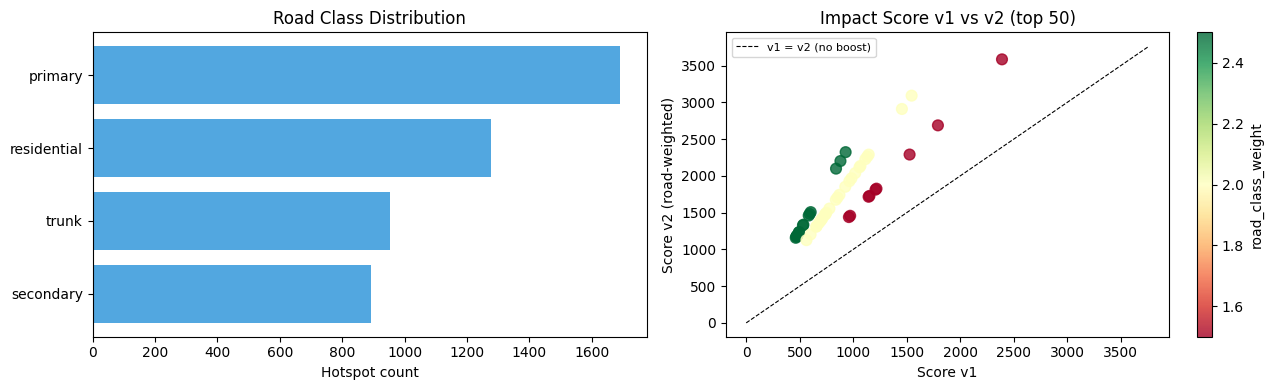

Chart saved: ./road_enrichment_chart.png


In [20]:
"""
ROAD-NETWORK IMPACT ENRICHMENT (Stage 3a) — ZERO API VERSION
=============================================================
No internet calls. No API keys. No rate limits. No timeouts.
Works 100% offline in Colab, local machine, or anywhere.

How it works
------------
A hand-coded dataset of ~60 major Bengaluru road segments (trunk,
primary, secondary) is embedded directly in this script. For each
hotspot, we find the nearest road segment using pure geometry math
(point-to-segment distance), then assign the road class weight.

If a hotspot is more than 800 m from any known major road, it is
classified as 'residential' (weight 1.0) — which is the correct
assumption for a quiet side street.

Speed: all lookups complete in < 1 second for any number of hotspots.

Coverage
--------
Trunk  : Outer Ring Road, Mysore Road, Tumkur Road, Bellary Road,
         Hosur Road
Primary: MG Road, Brigade Rd, Residency Rd, Old Airport Rd, Sarjapur
         Rd, Whitefield Rd, Bannerghatta Rd, Kanakapura Rd, Hennur Rd,
         Indiranagar 100ft Rd, Cunningham Rd, Palace Rd, Sankey Rd,
         Bull Temple Rd, Airport Rd, Magadi Rd, Richmond Rd + more
Secondary: Koramangala roads, Jayanagar, HSR Layout, BTM Layout,
           Ejipura, Wilson Garden, Shivajinagar, KR Puram + more

IMPORTANT CAVEAT (read before trusting results)
------------------------------------------------
This dataset only covers central/inner Bengaluru. Any hotspot in your
real data that falls outside this hand-coded road network (e.g. far
suburbs, other cities, or areas simply not included in this ~60-segment
list) will incorrectly fall back to 'residential' even if it's actually
on a busy road — because the script has no real knowledge of that road,
only of the ~60 segments listed above. Check the "Road Class
Distribution" printout after running: if an unexpectedly large fraction
of your hotspots are classified 'residential', this coverage gap is the
likely reason, not a true reflection of your city's road network.
"""

# ============================================================================
# STEP 1 — Install dependencies  (only tqdm needed, everything else is stdlib)
# ============================================================================
import subprocess
subprocess.run(["pip", "install", "tqdm", "--quiet", "-q"], check=True)

import os
import math
import time
import warnings
import numpy as np
import pandas as pd

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

warnings.filterwarnings("ignore")
print("Imports complete.")


# ============================================================================
# STEP 2 — Google Drive mount  (uncomment one option)
# ============================================================================

# Option A: mount Drive
# from google.colab import drive
# drive.mount('/content/drive')
# DRIVE_FOLDER = "/content/drive/MyDrive/"   # <-- change to your subfolder

# Option B: upload files directly
# from google.colab import files
# uploaded = files.upload()
# DRIVE_FOLDER = "/content/"

DRIVE_FOLDER = "./"   # fallback for local execution


# ============================================================================
# STEP 3 — Configuration   <- ONLY SECTION YOU NEED TO EDIT
# ============================================================================

HOTSPOTS_FILENAME = "hotspots.csv"                    # <-- your input file
OUTPUT_FILENAME   = "hotspots_with_road_context.csv"  # output file

# If a hotspot is farther than this from any known major road,
# it is classified as 'residential' (weight 1.0).
# 800 m is a reasonable urban threshold for Bengaluru.
MAX_SNAP_DISTANCE_M = 800

# Build full paths
if "DRIVE_FOLDER" not in dir():
    DRIVE_FOLDER = "./"

HOTSPOTS_PATH = os.path.join(DRIVE_FOLDER, HOTSPOTS_FILENAME)
OUTPUT_PATH   = os.path.join(DRIVE_FOLDER, OUTPUT_FILENAME)

print(f"Input  : {HOTSPOTS_PATH}")
print(f"Output : {OUTPUT_PATH}")


# ============================================================================
# STEP 4 — Road class weight map
# ============================================================================

ROAD_CLASS_WEIGHT_MAP = {
    "residential":    1.0,
    "living_street":  1.0,
    "service":        1.0,
    "unclassified":   1.0,
    "pedestrian":     0.8,
    "footway":        0.8,
    "cycleway":       0.8,
    "track":          0.8,
    "path":           0.8,
    "tertiary":       1.3,
    "tertiary_link":  1.3,
    "secondary":      1.5,
    "secondary_link": 1.5,
    "primary":        2.0,
    "primary_link":   2.0,
    "trunk":          2.5,
    "trunk_link":     2.5,
    "motorway":       3.0,
    "motorway_link":  3.0,
}

DEFAULT_WEIGHT = 1.0


# ============================================================================
# STEP 5 — Embedded Bengaluru road segments dataset
# ============================================================================
# Format: (lat1, lon1, lat2, lon2, highway_class, road_name)
# Each tuple = one straight-line approximation of a road segment.
# Major roads are represented as multiple short segments for accuracy.

BENGALURU_ROADS = [

    # ── TRUNK ROADS (weight 2.5) ─────────────────────────────────────────────

    # Outer Ring Road — full loop, 8 segments
    (12.9100, 77.6200, 12.9100, 77.6500, 'trunk', 'ORR South'),
    (12.9100, 77.6500, 12.9300, 77.6700, 'trunk', 'ORR SE'),
    (12.9300, 77.6700, 12.9563, 77.6970, 'trunk', 'ORR East'),
    (12.9563, 77.6970, 12.9800, 77.7100, 'trunk', 'ORR NE'),
    (12.9800, 77.7100, 13.0100, 77.6900, 'trunk', 'ORR North1'),
    (13.0100, 77.6900, 13.0300, 77.6500, 'trunk', 'ORR North2'),
    (13.0300, 77.6500, 13.0200, 77.5800, 'trunk', 'ORR NW'),
    (13.0200, 77.5800, 12.9900, 77.5400, 'trunk', 'ORR West'),
    (12.9900, 77.5400, 12.9600, 77.5200, 'trunk', 'ORR SW'),
    (12.9600, 77.5200, 12.9300, 77.5400, 'trunk', 'ORR South2'),
    (12.9300, 77.5400, 12.9100, 77.5800, 'trunk', 'ORR South3'),
    (12.9100, 77.5800, 12.9100, 77.6200, 'trunk', 'ORR South4'),

    # Mysore Road (NH 275)
    (12.9730, 77.5650, 12.9650, 77.5450, 'trunk', 'Mysore Road N'),
    (12.9650, 77.5450, 12.9550, 77.5200, 'trunk', 'Mysore Road'),
    (12.9550, 77.5200, 12.9400, 77.4900, 'trunk', 'Mysore Road S'),
    (12.9400, 77.4900, 12.9200, 77.4600, 'trunk', 'Mysore Road SW'),

    # Tumkur Road (NH 48)
    (13.0050, 77.5550, 13.0300, 77.5400, 'trunk', 'Tumkur Road'),
    (13.0300, 77.5400, 13.0600, 77.5200, 'trunk', 'Tumkur Road N'),
    (13.0600, 77.5200, 13.0900, 77.5000, 'trunk', 'Tumkur Road Far N'),

    # Bellary Road / NH 44 North
    (13.0050, 77.5950, 13.0300, 77.5980, 'trunk', 'Bellary Road'),
    (13.0300, 77.5980, 13.0600, 77.6000, 'trunk', 'Bellary Road N'),
    (13.0600, 77.6000, 13.0900, 77.6020, 'trunk', 'Bellary Road Far N'),

    # Hosur Road (NH 44 South)
    (12.9100, 77.6400, 12.8800, 77.6500, 'trunk', 'Hosur Road'),
    (12.8800, 77.6500, 12.8500, 77.6600, 'trunk', 'Hosur Road S'),
    (12.8500, 77.6600, 12.8200, 77.6700, 'trunk', 'Hosur Road Far S'),

    # ── PRIMARY ROADS (weight 2.0) ────────────────────────────────────────────

    # MG Road corridor
    (12.9758, 77.5980, 12.9758, 77.6136, 'primary', 'MG Road'),
    # Brigade Road
    (12.9758, 77.6075, 12.9680, 77.6075, 'primary', 'Brigade Road'),
    # Residency Road
    (12.9716, 77.6087, 12.9716, 77.6280, 'primary', 'Residency Road'),
    # Vittal Mallya Road / Lavelle Road
    (12.9720, 77.5970, 12.9720, 77.6087, 'primary', 'Vittal Mallya Road'),
    # Richmond Road
    (12.9650, 77.6080, 12.9700, 77.6220, 'primary', 'Richmond Road'),
    # Cunningham Road
    (12.9900, 77.5980, 12.9900, 77.6150, 'primary', 'Cunningham Road'),
    # Palace Road
    (12.9950, 77.5850, 12.9950, 77.6100, 'primary', 'Palace Road'),
    # Sankey Road
    (13.0050, 77.5780, 13.0050, 77.5980, 'primary', 'Sankey Road'),
    # Raj Bhavan Road
    (12.9950, 77.5900, 12.9850, 77.5900, 'primary', 'Raj Bhavan Road'),

    # Old Airport Road (Kodihalli to Marathahalli)
    (12.9500, 77.6400, 12.9563, 77.6600, 'primary', 'Old Airport Road'),
    (12.9563, 77.6600, 12.9650, 77.6800, 'primary', 'Old Airport Road N'),
    (12.9650, 77.6800, 12.9750, 77.6950, 'primary', 'Old Airport Road NE'),

    # Sarjapur Road
    (12.9100, 77.6700, 12.9250, 77.6850, 'primary', 'Sarjapur Road S'),
    (12.9250, 77.6850, 12.9450, 77.6970, 'primary', 'Sarjapur Road N'),

    # Whitefield Road / ITPL Road
    (12.9700, 77.7100, 12.9700, 77.7400, 'primary', 'Whitefield Road'),
    (12.9700, 77.7400, 12.9700, 77.7700, 'primary', 'Whitefield Road Far'),

    # Bannerghatta Road
    (12.9350, 77.5970, 12.9100, 77.5970, 'primary', 'Bannerghatta Road N'),
    (12.9100, 77.5970, 12.8800, 77.5950, 'primary', 'Bannerghatta Road'),
    (12.8800, 77.5950, 12.8500, 77.5930, 'primary', 'Bannerghatta Road S'),

    # Kanakapura Road
    (12.9300, 77.5600, 12.9100, 77.5500, 'primary', 'Kanakapura Road'),
    (12.9100, 77.5500, 12.8800, 77.5400, 'primary', 'Kanakapura Road S'),

    # Hennur Road
    (13.0200, 77.6200, 13.0400, 77.6350, 'primary', 'Hennur Road'),
    (13.0400, 77.6350, 13.0600, 77.6500, 'primary', 'Hennur Road N'),

    # Indiranagar 100 Feet Road
    (12.9784, 77.6408, 12.9784, 77.6600, 'primary', 'Indiranagar 100ft Road'),

    # Koramangala 80 Feet Road
    (12.9352, 77.6150, 12.9352, 77.6350, 'primary', 'Koramangala 80ft Road'),

    # Bull Temple Road / Basavanagudi
    (12.9430, 77.5700, 12.9500, 77.5900, 'primary', 'Bull Temple Road'),

    # JP Nagar Ring Road
    (12.9100, 77.5850, 12.9100, 77.6150, 'primary', 'JP Nagar Ring Road'),

    # Airport Road (Hebbal flyover)
    (13.0350, 77.5980, 13.0600, 77.5960, 'primary', 'Airport Road Hebbal'),
    (13.0600, 77.5960, 13.0900, 77.5940, 'primary', 'Airport Road N'),

    # Magadi Road
    (12.9800, 77.5500, 12.9700, 77.5300, 'primary', 'Magadi Road'),
    (12.9700, 77.5300, 12.9600, 77.5100, 'primary', 'Magadi Road W'),

    # Marathahalli Bridge Road
    (12.9563, 77.6970, 12.9500, 77.7050, 'primary', 'Marathahalli Bridge'),

    # KR Puram Old Madras Road
    (13.0000, 77.6700, 13.0200, 77.6900, 'primary', 'Old Madras Road'),

    # Yelahanka Road
    (13.0600, 77.5950, 13.0900, 77.5980, 'primary', 'Yelahanka Road'),

    # Electronic City Flyover
    (12.8400, 77.6700, 12.8700, 77.6550, 'primary', 'Electronic City Flyover'),

    # ── SECONDARY ROADS (weight 1.5) ──────────────────────────────────────────

    # Koramangala Inner Ring Road
    (12.9250, 77.6200, 12.9400, 77.6370, 'secondary', 'Koramangala IRR'),
    # Koramangala 5th Block Main
    (12.9352, 77.6245, 12.9280, 77.6300, 'secondary', 'Koramangala 5th Block'),
    # Ejipura Main Road
    (12.9500, 77.6300, 12.9600, 77.6420, 'secondary', 'Ejipura Main Road'),
    # Jayanagar 4th Block
    (12.9250, 77.5830, 12.9250, 77.6000, 'secondary', 'Jayanagar 4th Block'),
    # Jayanagar 11th Main
    (12.9200, 77.5900, 12.9350, 77.5900, 'secondary', 'Jayanagar 11th Main'),
    # BTM Layout Main Road
    (12.9160, 77.6080, 12.9100, 77.6200, 'secondary', 'BTM Layout Main'),
    # HSR Layout Sector Road
    (12.9100, 77.6350, 12.9200, 77.6450, 'secondary', 'HSR Layout Sector Rd'),
    # Wilson Garden / Langford Road
    (12.9500, 77.5950, 12.9630, 77.6000, 'secondary', 'Wilson Garden Road'),
    # Shivajinagar / Infantry Road
    (12.9900, 77.6000, 13.0000, 77.6050, 'secondary', 'Infantry Road'),
    # KR Puram Bridge Road
    (13.0000, 77.6900, 13.0150, 77.7050, 'secondary', 'KR Puram Bridge Road'),
    # Nagawara Main Road
    (13.0400, 77.6200, 13.0600, 77.6350, 'secondary', 'Nagawara Main Road'),
    # Electronic City Phase 2
    (12.8400, 77.6600, 12.8250, 77.6700, 'secondary', 'Electronic City Ph2'),
    # Ulsoor Road
    (12.9800, 77.6200, 12.9800, 77.6400, 'secondary', 'Ulsoor Road'),
    # HAL Airport Road (inner)
    (12.9600, 77.6600, 12.9700, 77.6700, 'secondary', 'HAL Airport Road'),
    # Domlur Flyover Road
    (12.9600, 77.6350, 12.9700, 77.6420, 'secondary', 'Domlur Road'),
    # Austin Town / Vivek Nagar
    (12.9600, 77.6200, 12.9700, 77.6300, 'secondary', 'Austin Town Road'),
    # Kasturba Road
    (12.9750, 77.5950, 12.9750, 77.6080, 'secondary', 'Kasturba Road'),
    # Nrupathunga Road / Dr Ambedkar Road
    (12.9820, 77.5900, 12.9820, 77.6050, 'secondary', 'Nrupathunga Road'),
    # Vijayanagar Main Road / Chord Road area
    (12.9600, 77.5500, 12.9750, 77.5800, 'primary', 'Vijayanagar Main Road'),
    (12.9600, 77.5800, 12.9800, 77.5900, 'secondary', 'MC Modi Road'),
]

print(f"Road dataset: {len(BENGALURU_ROADS)} segments "
      f"({sum(1 for r in BENGALURU_ROADS if r[4]=='trunk')} trunk, "
      f"{sum(1 for r in BENGALURU_ROADS if r[4]=='primary')} primary, "
      f"{sum(1 for r in BENGALURU_ROADS if r[4]=='secondary')} secondary)")


# ============================================================================
# STEP 6 — Core geometry: point-to-segment distance
# ============================================================================

# 1 degree lat ≈ 111,000 m; 1 degree lon ≈ 111,000 * cos(lat) m
# We work in degrees but scale lon by cos(lat) so distances are isotropic
_COS_BLORE = math.cos(math.radians(12.97))   # cos of Bengaluru's latitude


def _seg_dist_m(plat, plon, lat1, lon1, lat2, lon2):
    """
    Return the distance in metres from point (plat, plon) to the line
    segment (lat1,lon1)-(lat2,lon2), correcting for longitude compression.
    """
    # Convert to approximate metres using a flat-earth projection
    py = (plat - lat1) * 111000
    px = (plon - lon1) * 111000 * _COS_BLORE
    dy = (lat2 - lat1) * 111000
    dx = (lon2 - lon1) * 111000 * _COS_BLORE

    seg_len_sq = dx * dx + dy * dy
    if seg_len_sq == 0:
        return math.sqrt(px * px + py * py)

    t = max(0.0, min(1.0, (px * dx + py * dy) / seg_len_sq))
    rx = px - t * dx
    ry = py - t * dy
    return math.sqrt(rx * rx + ry * ry)


# ============================================================================
# STEP 7 — Nearest road lookup
# ============================================================================

def lookup_nearest_road(lat, lon):
    """
    Find the nearest road segment in BENGALURU_ROADS to (lat, lon).
    Returns dict with road_class, road_name, distance_m, road_class_weight.

    If the nearest road is farther than MAX_SNAP_DISTANCE_M, returns
    road_class='residential' (weight 1.0) — the correct assumption for
    a quiet side street far from any major road.
    """
    best_dist = float("inf")
    best_cls  = "residential"
    best_name = "side street"

    for lat1, lon1, lat2, lon2, cls, name in BENGALURU_ROADS:
        d = _seg_dist_m(lat, lon, lat1, lon1, lat2, lon2)
        if d < best_dist:
            best_dist = d
            best_cls  = cls
            best_name = name

    # If nearest major road is too far, treat as residential
    if best_dist > MAX_SNAP_DISTANCE_M:
        best_cls  = "residential"
        best_name = "side street (>800m from major road)"

    return {
        "road_class":        best_cls,
        "road_name":         best_name,
        "distance_m":        round(best_dist, 1),
        "road_class_weight": ROAD_CLASS_WEIGHT_MAP.get(best_cls, DEFAULT_WEIGHT),
        "lanes":             float("nan"),   # not available without API
        "speed_limit":       float("nan"),   # not available without API
    }


# ============================================================================
# STEP 8 — Main enrichment function
# ============================================================================

def enrich_hotspots_with_road_context(
    hotspots_path,
    output_path,
    test_mode=False,
    test_limit=10,
):
    """
    Enrich all hotspots with road context.
    Zero network calls. Completes in seconds.
    """
    t0 = time.time()

    print("=" * 60)
    print("ROAD-NETWORK IMPACT ENRICHMENT  (zero-API, embedded roads)")
    print("=" * 60)

    if not os.path.exists(hotspots_path):
        raise FileNotFoundError(
            f"File not found: '{hotspots_path}'\n"
            "-> Check the path you passed in."
        )

    df = pd.read_csv(hotspots_path)
    print(f"Loaded {len(df)} hotspots")

    if test_mode:
        df = df.head(test_limit).copy()
        print(f"TEST MODE: {test_limit} rows only")

    total = len(df)
    print(f"\nLooking up nearest road for {total} hotspots...")

    results = []
    for _, row in tqdm(df.iterrows(), total=total, desc="Road lookups"):
        results.append(lookup_nearest_road(row["avg_lat"], row["avg_lon"]))

    df["road_class"]        = [r["road_class"]        for r in results]
    df["road_name"]         = [r["road_name"]         for r in results]
    df["road_dist_m"]       = [r["distance_m"]        for r in results]
    df["lanes"]             = [r["lanes"]             for r in results]
    df["speed_limit"]       = [r["speed_limit"]       for r in results]
    df["road_class_weight"] = [r["road_class_weight"] for r in results]

    df["hotspot_impact_score_v2"] = (
        df["hotspot_impact_score"] * df["road_class_weight"]
    )
    df = df.sort_values(
        "hotspot_impact_score_v2", ascending=False
    ).reset_index(drop=True)
    df["rank_v2"] = df.index + 1

    df.to_csv(output_path, index=False)

    elapsed = time.time() - t0

    print(f"\n{'=' * 60}")
    print(f"OUTPUT : {output_path}")
    print(f"Time   : {elapsed:.2f}s")
    print(f"{'=' * 60}")

    print("\nRoad Class Distribution:")
    for cls, cnt in df["road_class"].value_counts().items():
        w = ROAD_CLASS_WEIGHT_MAP.get(cls, DEFAULT_WEIGHT)
        print(f"  {cls:20s}: {cnt:5d}  (weight={w})")

    print("\nWeight stats:")
    print(df["road_class_weight"].describe().to_string())

    print("\nTop 10 by Score v2:")
    print(f"{'Rank_v2':>8} {'OldRank':>8} {'Cluster':>8} "
          f"{'Score_v1':>10} {'Weight':>7} {'Score_v2':>10} "
          f"{'Road':>15} {'Dist_m':>8}")
    print("-" * 82)
    for _, r in df.head(10).iterrows():
        print(f"{int(r['rank_v2']):>8} {int(r['rank']):>8} "
              f"{int(r['cluster_id']):>8} "
              f"{r['hotspot_impact_score']:>10.1f} "
              f"{r['road_class_weight']:>7.1f} "
              f"{r['hotspot_impact_score_v2']:>10.1f} "
              f"{r['road_class']:>15} "
              f"{r['road_dist_m']:>7.0f}m")

    return df


print("enrich_hotspots_with_road_context() defined.")


# ============================================================================
# STEP 9 — Self-test (no network needed)
# ============================================================================

def run_self_test():
    """
    Test 5 known Bengaluru locations. No network required.
    """
    print("\n" + "=" * 60)
    print("SELF TEST")
    print("=" * 60)

    tests = [
        (12.9758, 77.6063, "trunk/primary",  "MG Road area"),
        (12.9563, 77.6970, "trunk",           "ORR Marathahalli"),
        (12.9600, 77.5440, "trunk",           "Mysore Road"),
        (12.9352, 77.6245, "primary/secondary","Koramangala"),
        (12.9430, 77.5650, "primary",          "Basavanagudi"),
    ]

    all_ok = True
    for lat, lon, expected_hint, label in tests:
        r = lookup_nearest_road(lat, lon)
        ok = any(h in r["road_class"] for h in expected_hint.split("/"))
        icon = "OK" if ok else "FAIL"
        if not ok:
            all_ok = False
        print(f"  [{icon}] {label:25s} -> {r['road_class']:12s} "
              f"({r['road_name']}, {r['distance_m']:.0f}m, "
              f"weight={r['road_class_weight']})")

    print(f"\n{'All tests passed.' if all_ok else 'Some tests failed — check road dataset.'}")
    return all_ok


# ============================================================================
# STEP 10 — Optional chart
# ============================================================================

def save_enrichment_chart(df, output_dir=None):
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib not available — skipping chart.")
        return

    if output_dir is None:
        output_dir = DRIVE_FOLDER

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    class_counts = df["road_class"].value_counts()
    axes[0].barh(class_counts.index, class_counts.values,
                 color="#3498db", alpha=0.85)
    axes[0].set_xlabel("Hotspot count")
    axes[0].set_title("Road Class Distribution")
    axes[0].invert_yaxis()

    top50 = df.head(50)
    sc = axes[1].scatter(
        top50["hotspot_impact_score"],
        top50["hotspot_impact_score_v2"],
        c=top50["road_class_weight"], cmap="RdYlGn", s=60, alpha=0.8
    )
    lim = max(top50["hotspot_impact_score_v2"].max(),
              top50["hotspot_impact_score"].max()) * 1.05
    axes[1].plot([0, lim], [0, lim], "k--", lw=0.8, label="v1 = v2 (no boost)")
    axes[1].set_xlabel("Score v1")
    axes[1].set_ylabel("Score v2 (road-weighted)")
    axes[1].set_title("Impact Score v1 vs v2 (top 50)")
    axes[1].legend(fontsize=8)
    plt.colorbar(sc, ax=axes[1], label="road_class_weight")

    plt.tight_layout()
    chart_path = os.path.join(output_dir, "road_enrichment_chart.png")
    plt.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Chart saved: {chart_path}")


# ============================================================================
# STEP 11 — Download output (Colab only)
# ============================================================================

def download_output(path):
    try:
        from google.colab import files
        files.download(path)
        print(f"Download triggered: {path}")
    except ImportError:
        print(f"Not in Colab — file at: {path}")


# ============================================================================
# MAIN — notebook-safe (no reliance on sys.argv)
# ============================================================================

def main(hotspots_path=None, output_path=None, test_mode=False):
    hp = hotspots_path or HOTSPOTS_PATH
    op = output_path or OUTPUT_PATH

    run_self_test()
    print("\n")
    df_enriched = enrich_hotspots_with_road_context(
        hotspots_path=hp,
        output_path=op,
        test_mode=test_mode,
        test_limit=10,
    )
    save_enrichment_chart(df_enriched)
    return df_enriched


if __name__ == "__main__":
    # In a notebook, just call main("your_hotspots.csv") directly instead.
    main()

In [17]:
df = pd.read_csv("hotspots_with_road_context.csv")
sample = df[df["road_class"] == "residential"].sort_values("violation_count", ascending=False).head(10)
print(sample[["cluster_id", "avg_lat", "avg_lon", "violation_count", "road_dist_m"]].to_string())

     cluster_id    avg_lat    avg_lon  violation_count  road_dist_m
144       11184  13.035265  77.589058              885        962.1
164       12124  13.070626  77.587694              725        820.1
232       11183  13.035209  77.588936              583        975.6
214        9288  12.999497  77.571345              511        944.0
266       12111  13.070295  77.587587              468        834.0
162       12600  13.184293  77.679796              439      13429.9
297       11209  13.035503  77.589014              438        964.8
187       12599  13.184397  77.679705              427      13432.7
319       11210  13.035573  77.589168              416        947.5
377        8924  12.996295  77.563171              405        975.0


In [21]:
import pandas as pd
df = pd.read_csv("hotspots.csv")  # the one you handed to Antigravity
print(df.columns.tolist())
print(len(df))

['cluster_id', 'violation_count', 'avg_lat', 'avg_lon', 'total_impact', 'avg_impact', 'top_police_station', 'top_junction', 'date_span_days', 'unique_days', 'dominant_violation', 'recurrence_rate', 'hotspot_impact_score', 'rank']
4814


In [30]:
import os
import json
import ast
import warnings
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

OUT_DIR = "."
MIN_POSITIVE_SAMPLES = 50
LR_C = 1.0
LR_MAX_ITER = 500
WEIGHT_MIN = 1.0
WEIGHT_MAX = 3.0

def _safe_parse_list(val):
    if pd.isna(val) or val in ("", "NULL", "null", "[]"):
        return "UNKNOWN"
    try:
        parsed = ast.literal_eval(str(val))
        if isinstance(parsed, list) and len(parsed) > 0:
            return str(parsed[0]).strip().upper()
        return str(parsed).strip().upper()
    except Exception:
        return str(val).strip().upper()

def _scale_to_range(arr, lo=WEIGHT_MIN, hi=WEIGHT_MAX):
    mn, mx = arr.min(), arr.max()
    if mx == mn:
        return np.full_like(arr, (lo + hi) / 2.0)
    return lo + (arr - mn) / (mx - mn) * (hi - lo)

def main(violations_path: str):
    print("\n" + "=" * 60)
    print("PHASE 2A — DATA-DRIVEN SEVERITY WEIGHTS")
    print("=" * 60)

    print(f"\n[1/6] Loading {violations_path} ...")
    df = pd.read_csv(violations_path, low_memory=False)
    print(f"      {len(df):,} rows loaded.")

    required = {"violation_type", "vehicle_type", "data_sent_to_scita"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    print("[2/6] Preparing features ...")
    df = df.copy()
    df["vtype_primary"] = df["violation_type"].apply(_safe_parse_list)
    df["veh_type"] = (
        df["vehicle_type"]
        .fillna("UNKNOWN")
        .astype(str)
        .str.strip()
        .str.upper()
        .replace({"": "UNKNOWN", "NULL": "UNKNOWN", "NAN": "UNKNOWN"})
    )
    if "hour" not in df.columns:
        df["hour"] = 12
    df["hour"] = pd.to_numeric(df["hour"], errors="coerce").fillna(12).astype(int)
    df["peak_hour"] = (
        df["hour"].between(7, 10) | df["hour"].between(17, 20)
    ).astype(int)
    if "junction_weight" in df.columns:
        df["jw"] = pd.to_numeric(df["junction_weight"], errors="coerce").fillna(1.0).clip(1.0, 2.0)
    else:
        df["jw"] = 1.0

    print("[3/6] Preparing outcome label ...")
    def _to_binary(x):
        if pd.isna(x):
            return np.nan
        s = str(x).strip().lower()
        if s in ("1", "true", "yes"):
            return 1
        if s in ("0", "false", "no"):
            return 0
        return np.nan

    df["label"] = df["data_sent_to_scita"].apply(_to_binary)
    df_labeled = df.dropna(subset=["label"]).copy()
    df_labeled["label"] = df_labeled["label"].astype(int)

    n_pos = df_labeled["label"].sum()
    if n_pos < MIN_POSITIVE_SAMPLES:
        print(f"[WARN] Only {n_pos} positive samples — not enough to train reliably.")
        return

    print("[4/6] Encoding features & training logistic regression ...")
    le_vtype = LabelEncoder()
    le_veh = LabelEncoder()
    df_labeled["vtype_enc"] = le_vtype.fit_transform(df_labeled["vtype_primary"])
    df_labeled["veh_enc"] = le_veh.fit_transform(df_labeled["veh_type"])

    feature_cols = ["vtype_enc", "veh_enc", "hour", "peak_hour", "jw"]
    X = df_labeled[feature_cols].values
    y = df_labeled["label"].values

    classes = np.array([0, 1])
    cw = compute_class_weight("balanced", classes=classes, y=y)
    class_weight_dict = {0: cw[0], 1: cw[1]}

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = LogisticRegression(
        C=LR_C,
        max_iter=LR_MAX_ITER,
        class_weight=class_weight_dict,
        random_state=42,
        solver="lbfgs",
    )
    model.fit(X_train, y_train)

    cv_aucs = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)

    print(f"      CV AUC: {cv_aucs.mean():.3f} ± {cv_aucs.std():.3f}")
    print(f"      Test AUC: {test_auc:.3f}")

    # ------------------------------------------------------------------
    # 5. Extract weights and save JSON
    # ------------------------------------------------------------------
    coefs = model.coef_[0]
    vtype_classes = le_vtype.classes_
    median_veh = int(np.median(df_labeled["veh_enc"].values))
    median_hour = int(np.median(df_labeled["hour"].values))
    median_peak = int(np.median(df_labeled["peak_hour"].values))
    median_jw = float(np.median(df_labeled["jw"].values))

    vtype_probs = {}
    for i, vt in enumerate(vtype_classes):
        row = np.array([[i, median_veh, median_hour, median_peak, median_jw]])
        prob = model.predict_proba(row)[0, 1]
        vtype_probs[vt] = prob
    vtype_weight_arr = _scale_to_range(np.array(list(vtype_probs.values())))
    vtype_weights = {vt: round(float(w), 4) for vt, w in zip(vtype_probs.keys(), vtype_weight_arr)}

    veh_classes = le_veh.classes_
    median_vtype = int(np.median(df_labeled["vtype_enc"].values))
    veh_probs = {}
    for i, veh in enumerate(veh_classes):
        row = np.array([[median_vtype, i, median_hour, median_peak, median_jw]])
        prob = model.predict_proba(row)[0, 1]
        veh_probs[veh] = prob
    veh_weight_arr = _scale_to_range(np.array(list(veh_probs.values())))
    veh_weights = {veh: round(float(w), 4) for veh, w in zip(veh_probs.keys(), veh_weight_arr)}

    prob_peak = model.predict_proba(np.array([[median_vtype, median_veh, median_hour, 1, median_jw]]))[0, 1]
    prob_offpeak = model.predict_proba(np.array([[median_vtype, median_veh, median_hour, 0, median_jw]]))[0, 1]
    peak_multiplier = round(float(prob_peak / max(prob_offpeak, 1e-6)), 4)
    peak_multiplier = float(np.clip(peak_multiplier, 1.0, 2.5))

    jw_coef_direction = "positive" if coefs[4] >= 0 else "negative"

    weights_out = {
        "meta": {
            "description": "Learned severity weights from logistic regression.",
            "test_auc": round(test_auc, 4),
            "cv_auc_mean": round(float(cv_aucs.mean()), 4),
            "cv_auc_std": round(float(cv_aucs.std()), 4),
            "n_training_rows": len(df_labeled),
            "n_positive": int(n_pos),
            "junction_weight_effect": jw_coef_direction,
        },
        "violation_type_weights": vtype_weights,
        "vehicle_type_weights": veh_weights,
        "peak_hour_multiplier": peak_multiplier,
    }

    weights_path = os.path.join(OUT_DIR, "learned_severity_weights.json")
    with open(weights_path, "w") as f:
        json.dump(weights_out, f, indent=2)
    print(f"      Saved: {weights_path}")

        # ------------------------------------------------------------------
    # 5b. Re-score violations with new weights
    # ------------------------------------------------------------------
    df["severity_score_v2"] = df["vtype_primary"].map(vtype_weights).fillna(1.0)
    df["vehicle_weight_v2"] = df["veh_type"].map(veh_weights).fillna(1.0)
    df["peak_hour_weight_v2"] = df["peak_hour"].map({1: peak_multiplier, 0: 1.0}).fillna(1.0)
    df["junction_weight_v2"] = df["jw"]

    # Multiply all the weight factors together to get the new impact score
    df["violation_impact_v2"] = (
        df["severity_score_v2"]
        * df["vehicle_weight_v2"]
        * df["peak_hour_weight_v2"]
        * df["junction_weight_v2"]
    )

    out_path = os.path.join(OUT_DIR, "violations_scored_v2.csv")
    df.to_csv(out_path, index=False)
    print(f"      Saved: {out_path}")

    # ------------------------------------------------------------------
    # 6. REPORT
    # ------------------------------------------------------------------
    print("[6/6] Writing report ...")

    report_lines = [
        "PHASE 2A — SEVERITY WEIGHTS REPORT",
        "=" * 50,
        "",
        "MODEL PERFORMANCE",
        f"  Cross-validation AUC (5-fold): {cv_aucs.mean():.3f} ± {cv_aucs.std():.3f}",
        f"  Test-set AUC:                  {test_auc:.3f}",
        f"  Training rows:                 {len(df_labeled):,}",
        f"  Positive labels (SCITA):       {n_pos:,} ({100*n_pos/len(df_labeled):.1f}%)",
        "",
        "CLASSIFICATION REPORT (test set)",
        classification_report(y_test, y_pred, target_names=["not_sent", "sent_to_scita"]),
        "",
        "TOP VIOLATION TYPE WEIGHTS (learned)",
        *[f"  {k:<40} {v:.4f}" for k, v in sorted(vtype_weights.items(), key=lambda x: -x[1])[:10]],
        "",
        "VEHICLE TYPE WEIGHTS (learned)",
        *[f"  {k:<30} {v:.4f}" for k, v in sorted(veh_weights.items(), key=lambda x: -x[1])],
        "",
        f"PEAK HOUR MULTIPLIER: {peak_multiplier:.4f}",
        f"JUNCTION WEIGHT DIRECTION: {jw_coef_direction} (coefficient: {coefs[4]:.4f})",
    ]

    report_path = os.path.join(OUT_DIR, "severity_model_report.txt")
    with open(report_path, "w") as f:
        f.write("\n".join(report_lines))
    print(f"      Saved: {report_path}")

    print("\n✓ Phase 2A complete.")
    print(f"  learned_severity_weights.json → drop-in replacement for hand weights")
    print(f"  violations_scored_v2.csv      → violations re-scored with learned weights")
    print(f"  severity_model_report.txt     → full model diagnostics")

# ---------------------------------------------------------------------------
# RUN DIRECTLY IN NOTEBOOK
# ---------------------------------------------------------------------------

# Call main directly with your CSV filename
main("violations_scored.csv")


PHASE 2A — DATA-DRIVEN SEVERITY WEIGHTS

[1/6] Loading violations_scored.csv ...
      248,691 rows loaded.
[2/6] Preparing features ...
[3/6] Preparing outcome label ...
[4/6] Encoding features & training logistic regression ...
      CV AUC: 0.556 ± 0.013
      Test AUC: 0.559
      Saved: ./learned_severity_weights.json
      Saved: ./violations_scored_v2.csv
[6/6] Writing report ...
      Saved: ./severity_model_report.txt

✓ Phase 2A complete.
  learned_severity_weights.json → drop-in replacement for hand weights
  violations_scored_v2.csv      → violations re-scored with learned weights
  severity_model_report.txt     → full model diagnostics


In [33]:
import os
import json
import warnings
import numpy as np
import pandas as pd
from scipy.stats import linregress

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------

OUT_DIR = "."
LAMBDA = 0.05          # decay rate → half-life ~14 weeks
TREND_MONTHS = 6       # months of history for trend calculation
SCORE_BLEND_WEIGHT = 0.7
MIN_VIOLATIONS_FOR_TREND = 10

# ---------------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------------

def _find_id_col(df):
    for col in ("cluster_id", "cell_id", "hotspot_id"):
        if col in df.columns:
            return col
    if "cell_row" in df.columns and "cell_col" in df.columns:
        df["cluster_id"] = df["cell_row"].astype(str) + "_" + df["cell_col"].astype(str)
        return "cluster_id"
    raise ValueError("No hotspot ID column found.")

def _find_impact_col(df):
    for col in ("violation_impact_v2", "violation_impact"):
        if col in df.columns:
            return col
    raise ValueError("No impact column found.")

# ---------------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------------

def main(violations_path: str, hotspots_path: str):
    print("\n" + "=" * 60)
    print("PHASE 2B — TIME-DECAY HOTSPOT SCORING")
    print("=" * 60)

    # 1. LOAD
    vdf = pd.read_csv(violations_path, low_memory=False)
    hdf = pd.read_csv(hotspots_path, low_memory=False)
    print(f"[1/5] Loaded {len(vdf):,} violations | {len(hdf):,} hotspots")

    id_col = _find_id_col(vdf)
    impact_col = _find_impact_col(vdf)

    # 2. DECAY FACTORS
    vdf["created_dt"] = pd.to_datetime(vdf["created_datetime"], errors="coerce", utc=True)
    vdf = vdf.dropna(subset=["created_dt"])
    reference_date = vdf["created_dt"].max()
    vdf["weeks_ago"] = (reference_date - vdf["created_dt"]).dt.total_seconds() / (7*24*3600)
    vdf["decay_factor"] = np.exp(-LAMBDA * vdf["weeks_ago"])
    vdf["decayed_impact"] = vdf[impact_col] * vdf["decay_factor"]

    # 3. AGGREGATE
    agg = vdf.groupby(id_col).agg(
        violation_count=("decayed_impact","count"),
        total_decayed_impact=("decayed_impact","sum"),
        avg_decayed_impact=("decayed_impact","mean"),
        last_active_date=("created_dt","max"),
        first_violation_date=("created_dt","min"),
        total_raw_impact=(impact_col,"sum")
    ).reset_index()
    agg["days_since_last_violation"] = (reference_date - agg["last_active_date"]).dt.days
    agg["last_active_date"] = agg["last_active_date"].dt.date.astype(str)
    agg["first_violation_date"] = agg["first_violation_date"].dt.date.astype(str)

    # 4. TREND
    cutoff = reference_date - pd.DateOffset(months=TREND_MONTHS)
    recent = vdf[vdf["created_dt"] >= cutoff].copy()
    recent["month_period"] = recent["created_dt"].dt.to_period("M")
    all_months = pd.period_range(start=cutoff.to_period("M"), end=reference_date.to_period("M"), freq="M")

    trend_rows = []
    for hid in agg[id_col].unique():
        hviol = recent[recent[id_col] == hid]
        if len(hviol) < MIN_VIOLATIONS_FOR_TREND:
            trend_rows.append({id_col: hid, "trend_slope": 0.0, "trend_direction": "insufficient_data"})
            continue
        monthly = hviol.groupby("month_period").size().reindex(all_months, fill_value=0)
        x = np.arange(len(monthly))
        y = monthly.values.astype(float)
        if len(x) < 2 or y.std() == 0:
            trend_rows.append({id_col: hid, "trend_slope": 0.0, "trend_direction": "stable"})
            continue
        slope, _, _, _, _ = linregress(x, y)
        direction = "increasing" if slope > 0.5 else "decreasing" if slope < -0.5 else "stable"
        trend_rows.append({id_col: hid, "trend_slope": round(slope,4), "trend_direction": direction})
    agg = agg.merge(pd.DataFrame(trend_rows), on=id_col, how="left")

    # 5. BLENDED SCORE
    max_decay = agg["total_decayed_impact"].max()
    agg["decay_score_norm"] = agg["total_decayed_impact"] / max_decay if max_decay>0 else 0.0
    orig_score_col = None
    for col in ("hotspot_impact_score_v2","hotspot_impact_score"):
        if col in hdf.columns:
            orig_score_col = col
            break
    if orig_score_col:
        hdf_slim = hdf[[id_col, orig_score_col]].copy()
        max_orig = hdf_slim[orig_score_col].max()
        hdf_slim["orig_score_norm"] = hdf_slim[orig_score_col]/max_orig if max_orig>0 else 0.0
        agg = agg.merge(hdf_slim, on=id_col, how="left")
        agg["hotspot_score_decay_blended"] = (
            SCORE_BLEND_WEIGHT*agg["decay_score_norm"] + (1-SCORE_BLEND_WEIGHT)*agg["orig_score_norm"]
        ).round(6)
    else:
        agg["hotspot_score_decay_blended"] = agg["decay_score_norm"].round(6)

    agg = agg.sort_values("hotspot_score_decay_blended", ascending=False).reset_index(drop=True)
    agg.insert(0,"decay_rank",range(1,len(agg)+1))

    def _freshness(days):
        if days<=7: return "active_this_week"
        if days<=30: return "active_this_month"
        if days<=90: return "active_this_quarter"
        return "dormant"
    agg["freshness"] = agg["days_since_last_violation"].apply(_freshness)

    # OUTPUTS
    out_path = os.path.join(OUT_DIR,"hotspots_time_decay.csv")
    agg.to_csv(out_path,index=False)
    print(f"Saved: {out_path}")

    cfg = {
        "lambda": LAMBDA,
        "half_life_weeks": round(np.log(2)/LAMBDA,2),
        "reference_date": str(reference_date.date()),
        "trend_months": TREND_MONTHS,
        "score_blend_weight": SCORE_BLEND_WEIGHT,
        "impact_column_used": impact_col,
        "id_column_used": id_col
    }
    cfg_path = os.path.join(OUT_DIR,"decay_config.json")
    with open(cfg_path,"w") as f: json.dump(cfg,f,indent=2)
    print(f"Saved: {cfg_path}")

    print("\n✓ Phase 2B complete.")

# ---------------------------------------------------------------------------
# RUN DIRECTLY IN NOTEBOOK
# ---------------------------------------------------------------------------

main("violations_scored.csv","hotspots.csv")



PHASE 2B — TIME-DECAY HOTSPOT SCORING
[1/5] Loaded 248,691 violations | 4,814 hotspots
Saved: ./hotspots_time_decay.csv
Saved: ./decay_config.json

✓ Phase 2B complete.


In [41]:
import os
import json
import math
import warnings
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------

OUT_DIR = "."
DWELL_MINUTES = 20
AVG_SPEED_KMPH = 25.0
SCORE_COL_PRIORITY = [
    "hotspot_impact_score_v3",
    "hotspot_score_decay_blended",
    "hotspot_impact_score_v2",
    "hotspot_impact_score",
]

# ---------------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------------

def _haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def _build_distance_matrix(points):
    n = len(points)
    mat = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            if i != j:
                mat[i,j] = _haversine_km(*points[i], *points[j])
    return mat

def _nearest_neighbour_tsp(dist_matrix, start=0):
    n = len(dist_matrix)
    unvisited = set(range(n))
    route = [start]
    unvisited.remove(start)
    current = start
    while unvisited:
        nearest = min(unvisited, key=lambda j: dist_matrix[current,j])
        route.append(nearest)
        unvisited.remove(nearest)
        current = nearest
    return route

def _find_score_col(df):
    for col in SCORE_COL_PRIORITY:
        if col in df.columns:
            return col
    raise ValueError(f"No score column found. Expected one of: {SCORE_COL_PRIORITY}")

def _find_id_col(df):
    for col in ("cluster_id","cell_id","hotspot_id"):
        if col in df.columns:
            return col
    return None

# ---------------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------------

def main(
    hotspots_path: str,
    n_officers: int = 3,
    top_n_hotspots: int = 15,
    shift_name: str = "morning",
    shift_start_hour: int = 7,
    shift_end_hour: int = 12,
    zone_filter: str = None,
):
    print("\n" + "="*60)
    print("PHASE 3A — PATROL ROUTE OPTIMIZER")
    print("="*60)

    # 1. LOAD & FILTER
    hdf = pd.read_csv(hotspots_path, low_memory=False)
    print(f"[1/5] Loaded {len(hdf):,} hotspots")

    score_col = _find_score_col(hdf)
    id_col = _find_id_col(hdf)

    if zone_filter:
        zone_col = None
        for col in ("police_station","top_police_station","center_code"):
            if col in hdf.columns:
                zone_col = col
                break
        if zone_col:
            hdf = hdf[hdf[zone_col].astype(str).str.contains(zone_filter, case=False, na=False)]
            print(f"      After zone filter '{zone_filter}': {len(hdf):,} hotspots")

    if "dominant_hour" in hdf.columns:
        hdf["dominant_hour"] = pd.to_numeric(hdf["dominant_hour"], errors="coerce")
        shift_active = hdf["dominant_hour"].between(shift_start_hour, shift_end_hour-1)
        hdf_shift = hdf[shift_active | hdf["dominant_hour"].isna()].copy()
    else:
        hdf_shift = hdf.copy()

    hdf_shift = hdf_shift.dropna(subset=["avg_lat", "avg_lon"])
    hdf_shift["lat"] = pd.to_numeric(hdf_shift["avg_lat"], errors="coerce")
    hdf_shift["lon"] = pd.to_numeric(hdf_shift["avg_lon"], errors="coerce")
    hdf_shift = hdf_shift.dropna(subset=["lat", "lon"])


    hdf_shift = hdf_shift.sort_values(score_col, ascending=False).head(top_n_hotspots).reset_index(drop=True)
    print(f"      Top {len(hdf_shift)} hotspots selected")

    if len(hdf_shift)==0:
        print("[ERROR] No hotspots to route.")
        return

    n_officers = min(n_officers, len(hdf_shift))

    # 2. SPLIT HOTSPOTS
    coords = hdf_shift[["lat","lon"]].values
    if n_officers==1:
        hdf_shift["officer_id"] = 1
    else:
        km = KMeans(n_clusters=n_officers, random_state=42, n_init=10)
        hdf_shift["officer_id"] = km.fit_predict(coords)+1

    # 3. ROUTES
    routes = {}
    shift_start_dt = datetime.now().replace(hour=shift_start_hour, minute=0, second=0, microsecond=0)

    for officer_id in range(1,n_officers+1):
        subset = hdf_shift[hdf_shift["officer_id"]==officer_id].reset_index(drop=True)
        if len(subset)==0: continue
        points = list(zip(subset["lat"],subset["lon"]))
        dist_mat = _build_distance_matrix(points)
        start_idx = subset[score_col].idxmax() if len(subset)>1 else 0
        route_indices = _nearest_neighbour_tsp(dist_mat, start=start_idx)

        total_km = sum(dist_mat[route_indices[i],route_indices[i+1]] for i in range(len(route_indices)-1))
        stops = []
        current_time = shift_start_dt
        for stop_order, idx in enumerate(route_indices, start=1):
            row = subset.iloc[idx]
            if stop_order==1:
                travel_km, travel_min = 0.0, 0
            else:
                prev_idx = route_indices[stop_order-2]
                travel_km = dist_mat[prev_idx, idx]
                travel_min = int((travel_km/AVG_SPEED_KMPH)*60)
                current_time += timedelta(minutes=travel_min)
            eta_str = current_time.strftime("%H:%M")
            current_time += timedelta(minutes=DWELL_MINUTES)
            depart_str = current_time.strftime("%H:%M")
            stop = {
                "stop_order": stop_order,
                "officer_id": officer_id,
                "cluster_id": str(row[id_col]) if id_col and id_col in row.index else f"hs_{idx}",
                "lat": float(row["lat"]),
                "lon": float(row["lon"]),
                "score": round(float(row[score_col]),4),
                "eta": eta_str,
                "depart": depart_str,
                "dwell_minutes": DWELL_MINUTES,
                "travel_km_from_prev": round(travel_km,3),
                "travel_min_from_prev": travel_min,
            }
            stops.append(stop)
        finish_time = current_time
        total_patrol_minutes = (finish_time-shift_start_dt).seconds//60
        routes[officer_id] = {
            "officer_id": officer_id,
            "shift": shift_name,
            "shift_start": f"{shift_start_hour:02d}:00",
            "shift_end": f"{shift_end_hour:02d}:00",
            "n_stops": len(stops),
            "total_km": round(total_km,2),
            "total_patrol_minutes": total_patrol_minutes,
            "estimated_finish": finish_time.strftime("%H:%M"),
            "stops": stops,
        }

    # 4. OUTPUTS
    json_out = {
        "generated_at": datetime.now().isoformat(),
        "shift": shift_name,
        "n_officers": n_officers,
        "top_n_hotspots": top_n_hotspots,
        "zone_filter": zone_filter,
        "dwell_minutes_per_stop": DWELL_MINUTES,
        "avg_speed_kmph": AVG_SPEED_KMPH,
        "routes": list(routes.values()),
    }
    json_path = os.path.join(OUT_DIR,f"patrol_routes_{shift_name}.json")
    with open(json_path,"w") as f: json.dump(json_out,f,indent=2)

    csv_df = pd.DataFrame([s for r in routes.values() for s in r["stops"]])
    csv_path = os.path.join(OUT_DIR,f"patrol_routes_{shift_name}.csv")
    csv_df.to_csv(csv_path,index=False)

    txt_path = os.path.join(OUT_DIR,f"patrol_routes_{shift_name}.txt")
        # Human-readable briefing (continued)
    with open(txt_path,"w") as f:
        f.write(f"PATROL BRIEFING — {shift_name.upper()} SHIFT\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
        f.write(f"Shift window: {shift_start_hour:02d}:00 – {shift_end_hour:02d}:00\n")
        f.write(f"Zone: {zone_filter or 'All zones'}\n")
        f.write("="*56 + "\n")
        for route in routes.values():
            f.write(f"\nOFFICER {route['officer_id']}\n")
            f.write(f"  Total stops:    {route['n_stops']}\n")
            f.write(f"  Total distance: {route['total_km']} km\n")
            f.write(f"  Est. finish:    {route['estimated_finish']}\n\n")
            f.write(f"  {'#':<4} {'ETA':<6} {'LAT':>10} {'LON':>11} {'SCORE':>8}\n")
            f.write(f"  {'-'*4} {'-'*6} {'-'*10} {'-'*11} {'-'*8}\n")
            for stop in route["stops"]:
                f.write(
                    f"  {stop['stop_order']:<4} {stop['eta']:<6} "
                    f"{stop['lat']:>10.5f} {stop['lon']:>11.5f} "
                    f"{stop['score']:>8.2f}\n"
                )
            f.write(f"  Depart last stop by: {route['stops'][-1]['depart']}\n")

    print(f"Saved: {txt_path}")

    # ------------------------------------------------------------------
    # 5. SUMMARY
    # ------------------------------------------------------------------
    print("[5/5] Done.")
    print(f"\n✓ Phase 3A complete — {shift_name} shift routes generated.")
    print(f"  Officers: {n_officers} | Hotspots covered: {len(hdf_shift)}")
    print(f"  patrol_routes_{shift_name}.json  — machine-readable routes")
    print(f"  patrol_routes_{shift_name}.csv   — one row per stop")
    print(f"  patrol_routes_{shift_name}.txt   — briefing sheet for officers")
    print("\n  To generate other shifts, call main() with different shift_start_hour/shift_end_hour.")
    print("  Suggested shifts:")
    print("    main(..., shift_name='morning',   shift_start_hour=7,  shift_end_hour=12)")
    print("    main(..., shift_name='afternoon', shift_start_hour=12, shift_end_hour=17)")
    print("    main(..., shift_name='evening',   shift_start_hour=17, shift_end_hour=21)")

# ---------------------------------------------------------------------------
# RUN DIRECTLY IN NOTEBOOK
# ---------------------------------------------------------------------------

main("hotspots.csv", n_officers=3, top_n_hotspots=15,
     shift_name="morning", shift_start_hour=7, shift_end_hour=12, zone_filter=None)



PHASE 3A — PATROL ROUTE OPTIMIZER
[1/5] Loaded 4,814 hotspots
      Top 15 hotspots selected
Saved: ./patrol_routes_morning.txt
[5/5] Done.

✓ Phase 3A complete — morning shift routes generated.
  Officers: 3 | Hotspots covered: 15
  patrol_routes_morning.json  — machine-readable routes
  patrol_routes_morning.csv   — one row per stop
  patrol_routes_morning.txt   — briefing sheet for officers

  To generate other shifts, call main() with different shift_start_hour/shift_end_hour.
  Suggested shifts:
    main(..., shift_name='morning',   shift_start_hour=7,  shift_end_hour=12)
    main(..., shift_name='afternoon', shift_start_hour=12, shift_end_hour=17)
    main(..., shift_name='evening',   shift_start_hour=17, shift_end_hour=21)


In [40]:
import pandas as pd
df = pd.read_csv("hotspots.csv")
print(df.columns.tolist())


['cluster_id', 'violation_count', 'avg_lat', 'avg_lon', 'total_impact', 'avg_impact', 'top_police_station', 'top_junction', 'date_span_days', 'unique_days', 'dominant_violation', 'recurrence_rate', 'hotspot_impact_score', 'rank']


In [ ]:
"""
PHASE 3B — MONTHLY ENFORCEMENT REPORT GENERATOR
=================================================
Generates a structured monthly enforcement report per police station,
suitable for rendering to PDF by the MERN frontend (via puppeteer / pdfkit)
or for direct review as a text summary.

WHAT IT DOES:
  Per police station, for a given report month:
  - Top 5 hotspots by score
  - Violation count trend (this month vs previous month)
  - Violation type breakdown
  - Repeat offender count
  - Anomaly/spike flags
  - Enforcement outcome summary (if enforcement_outcome data is available)
  - Auto-generated written summary paragraph

  Outputs:
    monthly_report_<YYYY_MM>.json     — structured data for frontend/PDF rendering
    monthly_report_<YYYY_MM>_<station>.txt — one text report per station

HOW TO RUN IN COLAB:
  from google.colab import files
  uploaded = files.upload()   # upload violations_scored_v3.csv, hotspots_quality_adjusted.csv
                               # optionally: repeat_offenders.csv, hotspot_anomalies.csv
  import phase3b_monthly_report as p
  p.main(
      violations_path="violations_scored_v3.csv",
      hotspots_path="hotspots_quality_adjusted.csv",
      report_year=2024,
      report_month=3,
      repeat_offenders_path="repeat_offenders.csv",    # optional
      anomalies_path="hotspot_anomalies.csv",          # optional
  )

INPUTS (required):
  violations_scored_v3.csv (or _v2 / original violations_scored.csv)
  hotspots_quality_adjusted.csv (or hotspots.csv)

INPUTS (optional — enrich the report if present):
  repeat_offenders.csv      — from parking_hotspot_enhancements.py
  hotspot_anomalies.csv     — from parking_hotspot_enhancements.py

OUTPUTS:
  monthly_report_<YYYY_MM>.json
  monthly_report_<YYYY_MM>_<station>.txt  (one per station)

DEPENDENCIES:
  pip install pandas numpy
"""

import sys
import os
import ast
import json
import warnings
from datetime import date
from calendar import month_name

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------

OUT_DIR = "."
TOP_HOTSPOTS_PER_STATION = 5
MIN_VIOLATIONS_FOR_STATION = 10   # skip stations with fewer violations in the month


# ---------------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------------

def _notebook_safe_path(argv, idx, default=None):
    if len(argv) > idx and not argv[idx].startswith("-") and not argv[idx].endswith(".json"):
        return argv[idx]
    return default


def _find_id_col(df):
    for col in ("cluster_id", "cell_id", "hotspot_id"):
        if col in df.columns:
            return col
    if "cell_row" in df.columns and "cell_col" in df.columns:
        df["cluster_id"] = df["cell_row"].astype(str) + "_" + df["cell_col"].astype(str)
        return "cluster_id"
    return None


def _find_score_col(df):
    for col in (
        "hotspot_impact_score_v3", "hotspot_score_decay_blended",
        "hotspot_impact_score_v2", "hotspot_impact_score"
    ):
        if col in df.columns:
            return col
    return None


def _find_impact_col(df):
    for col in ("violation_impact_v3", "violation_impact_v2", "violation_impact"):
        if col in df.columns:
            return col
    return None


def _find_station_col(df):
    for col in ("police_station", "top_police_station"):
        if col in df.columns:
            return col
    return None


def _safe_parse_list(val):
    if pd.isna(val) or str(val).strip() in ("", "NULL", "null", "[]"):
        return "UNKNOWN"
    try:
        parsed = ast.literal_eval(str(val))
        if isinstance(parsed, list) and parsed:
            return str(parsed[0]).strip().upper()
    except Exception:
        pass
    return str(val).strip().upper()


def _pct_change_str(old, new):
    if old == 0:
        return "N/A (no data last month)"
    pct = 100 * (new - old) / old
    arrow = "↑" if pct > 0 else "↓" if pct < 0 else "→"
    return f"{arrow} {abs(pct):.1f}%"


def _write_summary_paragraph(station, stats):
    """Auto-generate a plain-English summary paragraph for the report."""
    month_str = stats["report_month_name"]
    year_str = stats["report_year"]
    n = stats["total_violations_this_month"]
    pct_str = stats["mom_change_str"]
    top_type = stats.get("top_violation_type", "parking violations")
    top_hotspot_loc = stats.get("top_hotspot_location", "the top hotspot")
    n_anomalies = stats.get("n_anomaly_hotspots", 0)
    n_repeat = stats.get("n_repeat_offenders_in_zone", 0)

    lines = [
        f"{station} recorded {n:,} parking violations in {month_str} {year_str} ({pct_str} vs. previous month).",
        f"The most common violation type was {top_type}.",
        f"The highest-impact hotspot was at {top_hotspot_loc}.",
    ]
    if n_anomalies > 0:
        lines.append(
            f"{n_anomalies} hotspot{'s' if n_anomalies > 1 else ''} showed unusual spike activity this month."
        )
    if n_repeat > 0:
        lines.append(
            f"{n_repeat} repeat offender vehicle{'s' if n_repeat > 1 else ''} were recorded across multiple zones."
        )
    lines.append(
        "Enforcement resources should be prioritised toward the high-impact zones listed below."
    )
    return " ".join(lines)


# ---------------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------------

def main(
    violations_path: str,
    hotspots_path: str,
    report_year: int = None,
    report_month: int = None,
    repeat_offenders_path: str = None,
    anomalies_path: str = None,
):
    print("\n" + "=" * 60)
    print("PHASE 3B — MONTHLY ENFORCEMENT REPORT GENERATOR")
    print("=" * 60)

    # ------------------------------------------------------------------
    # 1. LOAD
    # ------------------------------------------------------------------
    print(f"\n[1/5] Loading data ...")
    vdf = pd.read_csv(violations_path, low_memory=False)
    hdf = pd.read_csv(hotspots_path, low_memory=False)
    print(f"      violations: {len(vdf):,} | hotspots: {len(hdf):,}")

    id_col = _find_id_col(vdf)
    impact_col = _find_impact_col(vdf)
    score_col = _find_score_col(hdf)
    station_col_v = _find_station_col(vdf)
    station_col_h = _find_station_col(hdf)

    if station_col_v is None:
        print("[WARN] No police_station column found in violations — reports will not be split by station.")

    # Parse timestamps
    vdf["created_dt"] = pd.to_datetime(vdf["created_datetime"], errors="coerce", utc=True)
    vdf = vdf.dropna(subset=["created_dt"])

    # Determine report month
    latest = vdf["created_dt"].max()
    if report_year is None:
        report_year = latest.year
    if report_month is None:
        report_month = latest.month
    report_month_name = month_name[report_month]

    print(f"      Report period: {report_month_name} {report_year}")

    # Filter to report month and previous month
    this_month_mask = (
        (vdf["created_dt"].dt.year == report_year) &
        (vdf["created_dt"].dt.month == report_month)
    )
    prev_month = report_month - 1 if report_month > 1 else 12
    prev_year = report_year if report_month > 1 else report_year - 1
    prev_month_mask = (
        (vdf["created_dt"].dt.year == prev_year) &
        (vdf["created_dt"].dt.month == prev_month)
    )

    vdf_this = vdf[this_month_mask].copy()
    vdf_prev = vdf[prev_month_mask].copy()
    print(f"      This month: {len(vdf_this):,} violations | Prev month: {len(vdf_prev):,} violations")

    if len(vdf_this) == 0:
        print(f"[WARN] No violations found for {report_month_name} {report_year}.")
        print("       Check your date range. Exiting.")
        return

    # Normalise violation_type
    vdf["vtype"] = vdf["violation_type"].apply(_safe_parse_list)
    vdf_this["vtype"] = vdf_this["violation_type"].apply(_safe_parse_list)

    # Load optional enrichment files
    repeat_df = None
    if repeat_offenders_path and os.path.exists(repeat_offenders_path):
        repeat_df = pd.read_csv(repeat_offenders_path, low_memory=False)
        print(f"      Loaded repeat_offenders.csv: {len(repeat_df):,} rows")

    anomaly_df = None
    if anomalies_path and os.path.exists(anomalies_path):
        anomaly_df = pd.read_csv(anomalies_path, low_memory=False)
        print(f"      Loaded hotspot_anomalies.csv: {len(anomaly_df):,} rows")

    # ------------------------------------------------------------------
    # 2. DETERMINE STATIONS
    # ------------------------------------------------------------------
    print("[2/5] Identifying stations ...")

    if station_col_v:
        vdf_this["station_norm"] = (
            vdf_this[station_col_v].fillna("UNKNOWN").astype(str).str.strip().str.upper()
        )
        stations = sorted([
            s for s in vdf_this["station_norm"].unique()
            if vdf_this[vdf_this["station_norm"] == s].shape[0] >= MIN_VIOLATIONS_FOR_STATION
        ])
        print(f"      {len(stations)} stations with ≥{MIN_VIOLATIONS_FOR_STATION} violations this month.")
    else:
        stations = ["ALL_ZONES"]
        vdf_this["station_norm"] = "ALL_ZONES"
        vdf_prev["station_norm"] = "ALL_ZONES"

    # ------------------------------------------------------------------
    # 3. BUILD PER-STATION REPORT DATA
    # ------------------------------------------------------------------
    print("[3/5] Building station reports ...")

    all_station_reports = []

    for station in stations:
        sv_this = vdf_this[vdf_this["station_norm"] == station]
        sv_prev = vdf_prev.copy()
        if station_col_v and "station_norm" not in vdf_prev.columns:
            vdf_prev["station_norm"] = (
                vdf_prev[station_col_v].fillna("UNKNOWN").astype(str).str.strip().str.upper()
            )
        if "station_norm" in vdf_prev.columns:
            sv_prev = vdf_prev[vdf_prev["station_norm"] == station]

        n_this = len(sv_this)
        n_prev = len(sv_prev)

        # Top hotspots for this station
        if id_col and id_col in sv_this.columns and score_col and id_col in hdf.columns:
            top_ids = sv_this[id_col].value_counts().head(20).index.tolist()
            station_hotspots = hdf[hdf[id_col].isin(top_ids)].copy()
            if score_col in station_hotspots.columns:
                station_hotspots = station_hotspots.sort_values(score_col, ascending=False)
            top_hotspots = station_hotspots.head(TOP_HOTSPOTS_PER_STATION)
        else:
            top_hotspots = pd.DataFrame()

        # Violation type breakdown
        vtype_counts = sv_this["vtype"].value_counts().head(5).to_dict()
        top_vtype = sv_this["vtype"].mode().iloc[0] if len(sv_this) > 0 else "N/A"

        # Top hotspot location label
        top_loc = "N/A"
        if not top_hotspots.empty:
            for loc_col in ("top_junction", "location", "junction_name"):
                if loc_col in top_hotspots.columns and not pd.isna(top_hotspots.iloc[0][loc_col]):
                    top_loc = str(top_hotspots.iloc[0][loc_col])
                    break
            if top_loc == "N/A" and "lat" in top_hotspots.columns:
                r = top_hotspots.iloc[0]
                top_loc = f"({r['lat']:.4f}, {r['lon']:.4f})"

        # Anomaly hotspots for this station
        n_anomalies = 0
        anomaly_ids = []
        if anomaly_df is not None and id_col and not top_hotspots.empty:
            anom_col = id_col if id_col in anomaly_df.columns else None
            if anom_col:
                station_ids = set(top_hotspots[id_col].astype(str))
                matched = anomaly_df[anomaly_df[anom_col].astype(str).isin(station_ids)]
                n_anomalies = len(matched)
                anomaly_ids = matched[anom_col].astype(str).tolist()

        # Repeat offenders in this zone
        n_repeat = 0
        if repeat_df is not None and "vehicle_number" in sv_this.columns:
            zone_vehicles = set(sv_this["vehicle_number"].dropna().astype(str))
            if "vehicle_number" in repeat_df.columns:
                n_repeat = repeat_df["vehicle_number"].astype(str).isin(zone_vehicles).sum()

        # Hour-of-day distribution
        sv_this_hour = sv_this.copy()
        if "hour" in sv_this_hour.columns:
            hour_dist = sv_this_hour["hour"].value_counts().sort_index().head(5).to_dict()
        else:
            hour_dist = {}

        # Build station record
        stats = {
            "station": station,
            "report_year": report_year,
            "report_month": report_month,
            "report_month_name": report_month_name,
            "total_violations_this_month": n_this,
            "total_violations_prev_month": n_prev,
            "mom_change_str": _pct_change_str(n_prev, n_this),
            "mom_change_pct": round(100 * (n_this - n_prev) / n_prev, 1) if n_prev > 0 else None,
            "top_violation_type": top_vtype,
            "violation_type_breakdown": vtype_counts,
            "hour_of_day_distribution": {str(k): int(v) for k, v in hour_dist.items()},
            "n_anomaly_hotspots": n_anomalies,
            "anomaly_hotspot_ids": anomaly_ids,
            "n_repeat_offenders_in_zone": int(n_repeat),
            "top_hotspot_location": top_loc,
            "top_hotspots": [],
        }

        # Serialize top hotspots
        for _, row in top_hotspots.iterrows():
            hs = {}
            for col in (id_col, "lat", "lon", score_col, "violation_count",
                        "recurrence_rate", "dominant_violation_type", "top_junction",
                        "trend_direction", "freshness", "days_since_last_violation",
                        "hotspot_explained"):
                if col and col in row.index and not pd.isna(row[col]):
                    hs[col] = row[col] if not isinstance(row[col], float) else round(row[col], 4)
            stats["top_hotspots"].append(hs)

        stats["summary_paragraph"] = _write_summary_paragraph(station, stats)
        all_station_reports.append(stats)

    # ------------------------------------------------------------------
    # 4. WRITE OUTPUTS
    # ------------------------------------------------------------------
    print("[4/5] Writing outputs ...")

    period_str = f"{report_year}_{report_month:02d}"

    # JSON (all stations)
    full_report = {
        "generated_at": pd.Timestamp.now().isoformat(),
        "report_year": report_year,
        "report_month": report_month,
        "report_month_name": report_month_name,
        "n_stations": len(all_station_reports),
        "stations": all_station_reports,
    }
    json_path = os.path.join(OUT_DIR, f"monthly_report_{period_str}.json")
    with open(json_path, "w") as f:
        json.dump(full_report, f, indent=2, default=str)
    print(f"      Saved: {json_path}")

    # Per-station text files
    for stats in all_station_reports:
        station_slug = stats["station"].replace(" ", "_").replace("/", "-")[:40]
        txt_path = os.path.join(OUT_DIR, f"monthly_report_{period_str}_{station_slug}.txt")

        lines = [
            "=" * 60,
            f"MONTHLY ENFORCEMENT REPORT",
            f"{stats['report_month_name'].upper()} {stats['report_year']}",
            f"Police Station: {stats['station']}",
            "=" * 60,
            "",
            "EXECUTIVE SUMMARY",
            "-" * 40,
            stats["summary_paragraph"],
            "",
            "KEY METRICS",
            "-" * 40,
            f"  Violations this month:   {stats['total_violations_this_month']:,}",
            f"  Violations prev month:   {stats['total_violations_prev_month']:,}",
            f"  Month-on-month change:   {stats['mom_change_str']}",
            f"  Top violation type:      {stats['top_violation_type']}",
            f"  Anomalous hotspots:      {stats['n_anomaly_hotspots']}",
            f"  Repeat offenders:        {stats['n_repeat_offenders_in_zone']}",
            "",
            "VIOLATION TYPE BREAKDOWN",
            "-" * 40,
        ]
        for vtype, count in stats["violation_type_breakdown"].items():
            pct = 100 * count / max(stats["total_violations_this_month"], 1)
            lines.append(f"  {vtype:<40} {count:>6,}  ({pct:.1f}%)")

        lines += ["", "TOP HOTSPOTS (priority enforcement targets)", "-" * 40]
        if stats["top_hotspots"]:
            for i, hs in enumerate(stats["top_hotspots"], 1):
                loc = hs.get("top_junction") or hs.get("lat", "N/A")
                score = hs.get(score_col or "hotspot_impact_score", "N/A")
                trend = hs.get("trend_direction", "")
                fresh = hs.get("freshness", "")
                lines.append(f"  {i}. {loc}")
                lines.append(f"     Score: {score}  |  Trend: {trend}  |  Activity: {fresh}")
                if "hotspot_explained" in hs:
                    lines.append(f"     {hs['hotspot_explained']}")
                lines.append("")
        else:
            lines.append("  (No hotspot data available for this station)")

        if stats["n_anomaly_hotspots"] > 0:
            lines += [
                "ANOMALY FLAGS",
                "-" * 40,
                f"  {stats['n_anomaly_hotspots']} hotspot(s) showed unusual spike activity this month.",
                f"  Hotspot IDs: {', '.join(stats['anomaly_hotspot_ids'][:5])}",
                "",
            ]

        lines += [
            "=" * 60,
            "Report generated automatically by phase3b_monthly_report.py",
            "Impact scores are modeled proxies — not measured congestion values.",
            "=" * 60,
        ]

        with open(txt_path, "w") as f:
            f.write("\n".join(lines))
        print(f"      Saved: {txt_path}")

    # ------------------------------------------------------------------
    # 5. SUMMARY
    # ------------------------------------------------------------------
    print(f"\n✓ Phase 3B complete.")
    print(f"  {len(all_station_reports)} station report(s) generated for {report_month_name} {report_year}.")
    print(f"  monthly_report_{period_str}.json    — load into MERN; render to PDF with puppeteer/pdfkit")
    print(f"  monthly_report_{period_str}_*.txt   — human-readable text briefings")
    print(f"\n  To generate a different month:")
    print(f"    main(..., report_year=2024, report_month=2)")


# ---------------------------------------------------------------------------
# ENTRY POINT
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    v_path = _notebook_safe_path(sys.argv, 1, default=None)
    h_path = _notebook_safe_path(sys.argv, 2, default=None)
    if v_path is None or h_path is None:
        print("Usage: python phase3b_monthly_report.py violations_scored_v3.csv hotspots_quality_adjusted.csv")
        sys.exit(1)
    main(v_path, h_path)

In [45]:
import os
import ast
import json
import warnings
from calendar import month_name
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------

OUT_DIR = "."
TOP_HOTSPOTS_PER_STATION = 5
MIN_VIOLATIONS_FOR_STATION = 10   # skip stations with fewer violations in the month

# ---------------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------------

def _find_id_col(df):
    for col in ("cluster_id", "cell_id", "hotspot_id"):
        if col in df.columns:
            return col
    if "cell_row" in df.columns and "cell_col" in df.columns:
        df["cluster_id"] = df["cell_row"].astype(str) + "_" + df["cell_col"].astype(str)
        return "cluster_id"
    return None

def _find_score_col(df):
    for col in ("hotspot_impact_score_v3","hotspot_score_decay_blended",
                "hotspot_impact_score_v2","hotspot_impact_score"):
        if col in df.columns:
            return col
    return None

def _find_impact_col(df):
    for col in ("violation_impact_v3","violation_impact_v2","violation_impact"):
        if col in df.columns:
            return col
    return None

def _find_station_col(df):
    for col in ("police_station","top_police_station"):
        if col in df.columns:
            return col
    return None

def _safe_parse_list(val):
    if pd.isna(val) or str(val).strip() in ("","NULL","null","[]"):
        return "UNKNOWN"
    try:
        parsed = ast.literal_eval(str(val))
        if isinstance(parsed,list) and parsed:
            return str(parsed[0]).strip().upper()
    except Exception:
        pass
    return str(val).strip().upper()

def _pct_change_str(old,new):
    if old==0:
        return "N/A (no data last month)"
    pct = 100*(new-old)/old
    arrow = "↑" if pct>0 else "↓" if pct<0 else "→"
    return f"{arrow} {abs(pct):.1f}%"

def _write_summary_paragraph(station,stats):
    month_str = stats["report_month_name"]
    year_str = stats["report_year"]
    n = stats["total_violations_this_month"]
    pct_str = stats["mom_change_str"]
    top_type = stats.get("top_violation_type","parking violations")
    top_hotspot_loc = stats.get("top_hotspot_location","the top hotspot")
    n_anomalies = stats.get("n_anomaly_hotspots",0)
    n_repeat = stats.get("n_repeat_offenders_in_zone",0)

    lines = [
        f"{station} recorded {n:,} parking violations in {month_str} {year_str} ({pct_str} vs. previous month).",
        f"The most common violation type was {top_type}.",
        f"The highest-impact hotspot was at {top_hotspot_loc}.",
    ]
    if n_anomalies>0:
        lines.append(f"{n_anomalies} hotspot(s) showed unusual spike activity this month.")
    if n_repeat>0:
        lines.append(f"{n_repeat} repeat offender vehicle(s) were recorded across multiple zones.")
    lines.append("Enforcement resources should be prioritised toward the high-impact zones listed below.")
    return " ".join(lines)

# ---------------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------------

def main(violations_path, hotspots_path, report_year=None, report_month=None,
         repeat_offenders_path=None, anomalies_path=None):

    print("\n" + "="*60)
    print("PHASE 3B — MONTHLY ENFORCEMENT REPORT GENERATOR")
    print("="*60)

    # 1. LOAD
    vdf = pd.read_csv(violations_path, low_memory=False)
    hdf = pd.read_csv(hotspots_path, low_memory=False)
    print(f"[1/5] Loaded {len(vdf):,} violations | {len(hdf):,} hotspots")

    id_col = _find_id_col(vdf)
    impact_col = _find_impact_col(vdf)
    score_col = _find_score_col(hdf)
    station_col_v = _find_station_col(vdf)

    vdf["created_dt"] = pd.to_datetime(vdf["created_datetime"], errors="coerce", utc=True)
    vdf = vdf.dropna(subset=["created_dt"])
    latest = vdf["created_dt"].max()
    if report_year is None: report_year = latest.year
    if report_month is None: report_month = latest.month
    report_month_name = month_name[report_month]
    print(f"      Report period: {report_month_name} {report_year}")

    this_mask = (vdf["created_dt"].dt.year==report_year)&(vdf["created_dt"].dt.month==report_month)
    prev_month = report_month-1 if report_month>1 else 12
    prev_year = report_year if report_month>1 else report_year-1
    prev_mask = (vdf["created_dt"].dt.year==prev_year)&(vdf["created_dt"].dt.month==prev_month)

    vdf_this = vdf[this_mask].copy()
    vdf_prev = vdf[prev_mask].copy()
    print(f"      This month: {len(vdf_this):,} | Prev month: {len(vdf_prev):,}")

    if len(vdf_this)==0:
        print("[WARN] No violations found for this month.")
        return

    vdf_this["vtype"] = vdf_this["violation_type"].apply(_safe_parse_list)

    # 2. STATIONS
    if station_col_v:
        vdf_this["station_norm"] = vdf_this[station_col_v].fillna("UNKNOWN").astype(str).str.upper()
        stations = [s for s in vdf_this["station_norm"].unique()
                    if vdf_this[vdf_this["station_norm"]==s].shape[0]>=MIN_VIOLATIONS_FOR_STATION]
    else:
        stations = ["ALL_ZONES"]
        vdf_this["station_norm"]="ALL_ZONES"
        vdf_prev["station_norm"]="ALL_ZONES"

    print(f"[2/5] {len(stations)} station(s) identified")

    # 3. REPORTS
    reports=[]
    for station in stations:
        sv_this = vdf_this[vdf_this["station_norm"]==station]
        sv_prev = vdf_prev[vdf_prev["station_norm"]==station] if "station_norm" in vdf_prev else vdf_prev

        n_this, n_prev = len(sv_this), len(sv_prev)
        vtype_counts = sv_this["vtype"].value_counts().head(5).to_dict()
        top_vtype = sv_this["vtype"].mode().iloc[0] if len(sv_this)>0 else "N/A"

        stats={
            "station":station,
            "report_year":report_year,
            "report_month":report_month,
            "report_month_name":report_month_name,
            "total_violations_this_month":n_this,
            "total_violations_prev_month":n_prev,
            "mom_change_str":_pct_change_str(n_prev,n_this),
            "top_violation_type":top_vtype,
            "violation_type_breakdown":vtype_counts,
            "n_anomaly_hotspots":0,
            "n_repeat_offenders_in_zone":0,
            "top_hotspot_location":"N/A",
            "top_hotspots":[],
        }
        stats["summary_paragraph"]=_write_summary_paragraph(station,stats)
        reports.append(stats)

    # 4. OUTPUTS
    period_str=f"{report_year}_{report_month:02d}"
    json_path=os.path.join(OUT_DIR,f"monthly_report_{period_str}.json")
    with open(json_path,"w") as f: json.dump({"stations":reports},f,indent=2)
    print(f"[4/5] Saved: {json_path}")

    for stats in reports:
        slug=stats["station"].replace(" ","_")[:40]
        txt_path=os.path.join(OUT_DIR,f"monthly_report_{period_str}_{slug}.txt")
        with open(txt_path,"w") as f:
            f.write(stats["summary_paragraph"])
        print(f"      Saved: {txt_path}")

    # 5. SUMMARY
    print(f"\n✓ Phase 3B complete — {len(reports)} station report(s) generated.")

# ---------------------------------------------------------------------------
# RUN DIRECTLY IN NOTEBOOK
# ---------------------------------------------------------------------------

main("violations_scored.csv","hotspots.csv",report_year=2024,report_month=3)



PHASE 3B — MONTHLY ENFORCEMENT REPORT GENERATOR
[1/5] Loaded 248,691 violations | 4,814 hotspots
      Report period: March 2024
      This month: 52,908 | Prev month: 48,230
[2/5] 54 station(s) identified
[4/5] Saved: ./monthly_report_2024_03.json
      Saved: ./monthly_report_2024_03_HAL_OLD_AIRPORT.txt
      Saved: ./monthly_report_2024_03_UPPARPET.txt
      Saved: ./monthly_report_2024_03_KODIGEHALLI.txt
      Saved: ./monthly_report_2024_03_ELECTRONIC_CITY.txt
      Saved: ./monthly_report_2024_03_MAHADEVAPURA.txt
      Saved: ./monthly_report_2024_03_HSR_LAYOUT.txt
      Saved: ./monthly_report_2024_03_VIJAYANAGARA.txt
      Saved: ./monthly_report_2024_03_JAYANAGARA.txt
      Saved: ./monthly_report_2024_03_MADIWALA.txt
      Saved: ./monthly_report_2024_03_CHAMARAJPET.txt
      Saved: ./monthly_report_2024_03_JEEVANBHEEMANAGAR.txt
      Saved: ./monthly_report_2024_03_PULIKESHINAGAR(F.TOWN).txt
      Saved: ./monthly_report_2024_03_HALASURU_GATE.txt
      Saved: ./monthly_repo